## Events from posthog

In [71]:
import json
df = pd.read_parquet("~/Clients/simplesystem/code/analytics/data/events.parquet")
# Parse the 'items' column JSON strings into Python lists of dicts
df["items"] = df["items"].apply(json.loads)

# Flatten the DataFrame so each item in the 'items' list gets its own row,
# while duplicating the other columns appropriately.
df = df.explode("items")

# Expand the dictionaries in the 'items' column into separate columns,
# prefixing each key with "product_"
items_df = pd.json_normalize(df["items"], sep='_')
items_df = items_df.add_prefix("product_")

# Drop the old 'items' column and add the expanded columns
df = df.drop(columns=["items"]).reset_index(drop=True)
df = pd.concat([df, items_df], axis=1)

# product_prefix = product_id up to the first ":"
df["product_prefix"] = df["product_id"].str.split(":", n=1).str[0]

# Keep only the first row per product_prefix
df = df.drop_duplicates(subset=["query_id", "product_prefix"], keep="first").reset_index(drop=True)

df.sort_values(by="query_id")


,query_id,query_term,hit_count,browser_language,geoip_country_code,timestamp,session_id,user_id,click_count,cart_count,avg_click_position,product_ean,product_id,product_name,product_prefix
59862,00008f4d-48e2-5187-b4c3-17b15589e98d,Iqsl 148 g,22,de-DE,DE,2026-02-09T07:34:44.449000+01:00,019c411a-fa88-71d4-abe6-4e8a3304f9cd,e61129a4-cd9b-44ac-8936-152356878c23,1,1,0.0,00000000,4xknDuwbEAYSKdENyEPDXp:SVFTTCAxNDggRw,"Winkel-Steckanschluss G 1/4""-8mm, IQS-Standard",4xknDuwbEAYSKdENyEPDXp
17283,00012d4e-0236-569c-b630-af3e537f9cc4,99-5125-15-07,4,de-DE,DE,2026-02-03T11:41:06.666000+01:00,019c2317-571b-750f-b390-b4bed5e21015,18ece1e3-0ad6-4160-9d98-6532281d78de,1,0,3.0,2050000420863,7cCLPI9rPbI8IxxCK5zddA:NzM4NTQ3LTVL,"binder 99-5125-15-07 Rundstecker Stecker, gera...",7cCLPI9rPbI8IxxCK5zddA
17282,00012d4e-0236-569c-b630-af3e537f9cc4,99-5125-15-07,4,de-DE,DE,2026-02-03T11:41:06.666000+01:00,019c2317-571b-750f-b390-b4bed5e21015,18ece1e3-0ad6-4160-9d98-6532281d78de,1,0,3.0,00000000,6SMy7wMzyAuaFrwuYbmpuM:Uy0yOTQ5ODcw,"BINDER 99-5125-15-07 RUNDSTECKER, 7POS, KABEL",6SMy7wMzyAuaFrwuYbmpuM
17284,00012d4e-0236-569c-b630-af3e537f9cc4,99-5125-15-07,4,de-DE,DE,2026-02-03T11:41:06.666000+01:00,019c2317-571b-750f-b390-b4bed5e21015,18ece1e3-0ad6-4160-9d98-6532281d78de,1,0,3.0,5059041991155,M1doDzIs2o1PQwQ9rPyIx:MTE1LTI1NjI,"Binder 423 Stecker Mini zur Kabelmontage, 7-po...",M1doDzIs2o1PQwQ9rPyIx
17285,00012d4e-0236-569c-b630-af3e537f9cc4,99-5125-15-07,4,de-DE,DE,2026-02-03T11:41:06.666000+01:00,019c2317-571b-750f-b390-b4bed5e21015,18ece1e3-0ad6-4160-9d98-6532281d78de,1,0,3.0,4099889727913,7DAV4kjRkUknAZ8gY7GRZK:NjZGNTky,"Stecker, 7-polig, Lötkelch, Schraubverriegelun...",7DAV4kjRkUknAZ8gY7GRZK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175688,ffffc316-7382-508e-bb63-298ec6086587,07521,7,de,DE,2026-02-23T07:46:35.987000+01:00,019c8923-102e-77d9-9092-666de88cb946,032f3c5c-19b4-4223-835f-ac431cba5215,1,1,4.0,3134375383271,6PwLdOwWw4u71yWlyGZDee:NTU2MTUwIDI4MA,Schleifvlies-Hand-Pads Rolle mit 60 Stück Mult...,6PwLdOwWw4u71yWlyGZDee
175687,ffffc316-7382-508e-bb63-298ec6086587,07521,7,de,DE,2026-02-23T07:46:35.987000+01:00,019c8923-102e-77d9-9092-666de88cb946,032f3c5c-19b4-4223-835f-ac431cba5215,1,1,4.0,00000000,6SMy7wMzyAuaFrwuYbmpuM:Uy0yNTE5NzUz,IMO PRECISION CONTROLS XKL-075-21 WECHSELRICHT...,6SMy7wMzyAuaFrwuYbmpuM
175686,ffffc316-7382-508e-bb63-298ec6086587,07521,7,de,DE,2026-02-23T07:46:35.987000+01:00,019c8923-102e-77d9-9092-666de88cb946,032f3c5c-19b4-4223-835f-ac431cba5215,1,1,4.0,0088381179089,4OuqCoxfB93TMJ3PIASlMX:OTUxNDk3Mjc,Schlangenbohrer Durchmesser 26 mm Länge 400 mm...,4OuqCoxfB93TMJ3PIASlMX
175685,ffffc316-7382-508e-bb63-298ec6086587,07521,7,de,DE,2026-02-23T07:46:35.987000+01:00,019c8923-102e-77d9-9092-666de88cb946,032f3c5c-19b4-4223-835f-ac431cba5215,1,1,4.0,4103810075018,7cCLPI9rPbI8IxxCK5zddA:ODExMzU1LTVL,Pressol 07521 Messbecher 1 l Polyethylen,7cCLPI9rPbI8IxxCK5zddA


In [88]:
# Robust JSONL read (avoids "Trailing data" / "Expected object or value" from pd.read_json)
import json

def read_jsonl(path):
    """Read newline-delimited JSON; skips blank lines and handles lines with trailing data."""
    rows = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except (json.JSONDecodeError, ValueError) as e:
                if "Extra data" in str(e) or "Trailing data" in str(e):
                    obj, _ = json.JSONDecoder().raw_decode(line)
                    rows.append(obj)
                else:
                    raise
    return pd.DataFrame(rows)

# Usage instead of pd.read_json(..., lines=True):
df = read_jsonl("/Users/max/Clients/max/ecomsearch/annotatorv3/outputs/2026-03-02/20-14-02/annotations_extracted.jsonl")

JSONDecodeError: Expecting property name enclosed in double quotes: line 1 column 2 (char 1)

In [75]:
df.to_parquet("~/Clients/simplesystem/code/analytics/data/extracted.parquet")

In [74]:
df.sort_values(by="query_id")[["query_term", "hit_count", "session_id", "user_id", "product_name"]].sample(50)

,query_term,hit_count,session_id,user_id,product_name
141353,atlas,5265,019c6f8d-34b9-7c7a-acf3-674a9c95119b,f3d206e2-1873-40d7-b44f-8b2bc249af2d,Stabmaterialständer ATLAS ST für META Kragarmr...
127950,4014651446939,27,019c6704-da9b-7cec-90bc-0c5abecf1294,ff030b88-7be7-46d0-8aec-44c8aa6b5560,"Multimeter MM 2-3 0,1 mV-1000 V AC,0,1 mV-1000..."
180845,GX 160,9,019c8a0f-dc56-7f50-b9e7-4a9f297b45fc,a97f0d29-a51e-4e04-be30-b0f5894f0105,GX 160 ESD - S1 - W10 - Gr.35
167564,Doppel-Monitorarm,12,019c7a15-e13b-7c88-ade7-c81d191d290a,1f19d771-1009-4bb2-af95-cfb5a573460f,"Doppel-Monitorarm Eppa(TM), schwarz FELLOWES 9..."
3555,668450,5,019c1d6b-cbd1-7406-abb8-13f8b858f33d,acbc03a1-f98d-461a-a71d-d701f227814b,LTS Licht&Leuchten LED-Stromschienenstrahler 9...
211151,torx set,895,019c95a2-27a5-744f-8312-32cec0d1b855,be5c6474-3ef0-4bf5-acd2-a7f3ecbdb5cd,Käfigmuttern-Set 50xM6 Torx zur Frontmontage
106699,ssd,21437,019c5229-527c-7515-b2ad-16db202fbf94,061bbd5c-af3e-467c-b94c-cc2e3f7a040c,GL7-SSD | Speichermodul für GL7000 Solid-State...
12485,1 ohr klemme,148,019c2241-6abb-7f61-827d-119ed62469e7,2360a1d9-c49e-4748-92f4-aaafbea52fcd,"1-Ohr-Schl.klemme, Einlagering, ES (W4), 10,0-..."
192803,5SY6102-7,5,019c8f11-8b78-764f-b711-bca0c9321ac3,6bf0b2f2-6afa-426c-b49f-6ff834bf3005,Siemens 5SY61027 5SY6102-7 Leitungsschutzschal...
125986,gasdruckfeder,165,019c668d-e70f-74b8-bf31-005cd3a82c9b,3ad8f8c6-b8d7-4e35-a41d-3b2bf3bc609e,"Schwenkarm, zur Befestigung an Aufsatzholmen, ..."


In [93]:
pd.read_json("/Users/max/Clients/max/ecomsearch/annotatorv3/outputs/2026-03-02/20-14-02/annotations_extracted.jsonl", lines=True)

,query_id,query_term,hit_count,browser_language,geoip_country_code,timestamp,session_id,user_id,click_count,cart_count,avg_click_position,product_ean,product_id,product_name,product_prefix,label
0,b341d50a-f3b0-51d8-addf-02748da6cf2e,082882,13,de-DE,DE,2026-01-31 21:30:30.639000+01:00,019c15bf-632a-72bf-ae1d-738521bd751b,911f8c9d-31eb-48c6-90f2-6a6a1666edc5,1,0,11.000000,4015080828822,7DAV4kjRkUknAZ8gY7GRZK:ODJQMDY5OA,"Hilfsschalter, 1 A, 250 VDC, 1 Schließer + 1 Ö...",7DAV4kjRkUknAZ8gY7GRZK,Exact
1,b341d50a-f3b0-51d8-addf-02748da6cf2e,082882,13,de-DE,DE,2026-01-31 21:30:30.639000+01:00,019c15bf-632a-72bf-ae1d-738521bd751b,911f8c9d-31eb-48c6-90f2-6a6a1666edc5,1,0,11.000000,4010995038472,2MXI5pDnjmyEkoMkBdhv7R:MDgyODgyIDI,"Schrauben-Ausdreher für Nr. 082880, passend fü...",2MXI5pDnjmyEkoMkBdhv7R,Irrelevant
2,b341d50a-f3b0-51d8-addf-02748da6cf2e,082882,13,de-DE,DE,2026-01-31 21:30:30.639000+01:00,019c15bf-632a-72bf-ae1d-738521bd751b,911f8c9d-31eb-48c6-90f2-6a6a1666edc5,1,0,11.000000,4064161268842,7cCLPI9rPbI8IxxCK5zddA:MTQzNDI2Mi01Sw,Eaton 082882 NHI-E-11-PKZ0 Hilfsschalter Einba...,7cCLPI9rPbI8IxxCK5zddA,Exact
3,640af114-d4f8-5255-91a7-0f7f7e4a0f64,iphone 16,876,es,DE,2026-01-31 22:51:44.612000+01:00,019c160a-3011-7196-8227-cefedcb0fdde,b8412318-8178-488d-a22f-7019ed1b02ee,1,1,11.333333,0,3yAxpSj8ig7qxWgy0oQc3b:MTk3MTcyOTg,"Hama 222781 Schutzglas, Iphone 16",3yAxpSj8ig7qxWgy0oQc3b,Complement
4,7f9c686e-a05a-5ea3-96d6-7ea982d9d7d9,Spritzpistole,71,de,DE,2026-01-31 22:22:42.231000+01:00,019c15e8-d6ed-7f59-b249-e8a6446fe668,53c7cc6e-1f65-44bc-b94d-8d074c0e7f3e,1,0,20.000000,0,1jG52jwaFt5Kh9UnOGSKKg:OTI1MDUxNw,SPP N1 Spritzpistole Allround,1jG52jwaFt5Kh9UnOGSKKg,Exact
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20332,6d151129-d802-5c8c-b0e2-ec041b324f6c,pistole,282,de-DE,DE,2026-02-03 13:58:52.455000+01:00,019c2392-262d-7ee2-9bde-9730202b3c4d,3c91b6f3-3d19-4908-add8-18190752fe2b,1,0,0.000000,4066407024816,3O67wTijRUrcGvmaPgw4MV:MTAwNjg4Mjkw,Gardena Classic Reinigungs- pistole (18360-20),3O67wTijRUrcGvmaPgw4MV,Exact
20333,8cc63530-b748-50ae-a96c-1c39747277a9,643333,7,de,DE,2026-02-03 13:59:48.955000+01:00,019c238d-c1b0-7b7c-9077-54a4b9f41eb7,6da7648e-bd12-47d2-b436-a3f92eb408ba,1,1,0.000000,4000896232369,6PwLdOwWw4u71yWlyGZDee:NjQzMzMzIDY,"6-kant-Schraubendreher-Einsatz, 1/2 Zoll, lang...",6PwLdOwWw4u71yWlyGZDee,Irrelevant
20334,a52cdf37-fd5c-5368-b645-bab22bd3dd69,crisp,49,de-DE,DE,2026-02-03 13:50:30.829000+01:00,019c2387-bd9a-7800-98b2-3f87e45b0f65,0bbdcdff-e0f1-4a86-a6e2-aabafc1207d9,1,1,0.000000,0,3yAxpSj8ig7qxWgy0oQc3b:MTExNjYxMzI,"Hellma Crisp&Creamy Mix, Kekse aus Mürbeteig, ...",3yAxpSj8ig7qxWgy0oQc3b,Substitute
20335,eb6b1f0f-e074-52e2-bf21-6477ac07c8b6,955844140,10,de,DE,2026-02-03 13:54:14.661000+01:00,019c2383-2f83-7b09-88e1-6afbb1db6476,d1345762-71c1-4555-896a-527014ab28ef,1,1,0.000000,4317784095372,3EmaQSQKdpPGF7MYE9Rx6j:MTU1ODk5NA,9558440140 # Winkelschraubendreher Lang DIN 91...,3EmaQSQKdpPGF7MYE9Rx6j,Substitute


## Articles / offers (mongodb)

In [1]:
import duckdb

In [4]:
duckdb.sql("SELECT format('{:t,}', count(*)) FROM '/Users/max/Clients/simplesystem/data/offers.parquet'").show()
duckdb.sql("SELECT * FROM '/Users/max/Clients/simplesystem/data/offers.parquet' LIMIT 5").df().iloc[0]


┌───────────────────────────────┐
│ format('{:t,}', count_star()) │
│            varchar            │
├───────────────────────────────┤
│ 521,763,985                   │
└───────────────────────────────┘



_id                                                   632355716dfe319319a2d175
article_number                                                      1572975-BP
catalog_version_id_b64                                Ol6tRkP4TZih59/KTuI4LA==
vendor_id_b64                                         0k7yLsf/QxKFVrBsJoC4FA==
offer_id_b64                                          JNn3gfiWRAerN0ExCp2QNQ==
name                         Relais de sécurité PSR-SPP-24DC/MXF1/4X1/2X2/B...
features                                                                    []
keywords                     [Phoenix Contact, 2902726, PSR-SPP-24DC/MXF1/4...
categoryPaths                [{'elements': ['04 - Composants actifs', 'Capt...
description                  Relais de sécurité<br /><br />Phoenix Contact ...
ean                                                              4046356673013
manufacturerName                                               Phoenix Contact
manufacturerArticleNumber                           

In [9]:
duckdb.sql("""
SELECT
    format('{:t,}', count(*))
    FROM (
        SELECT
            DISTINCT name, description, manufacturerName, article_number,
        FROM '/Users/max/Clients/simplesystem/data/offers.parquet'
    )
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌───────────────────────────────┐
│ format('{:t,}', count_star()) │
│            varchar            │
├───────────────────────────────┤
│ 141,685,460                   │
└───────────────────────────────┘

In [ ]:
duckdb.sql("""
SELECT
    format('{:t,}', count(DISTINCT article_number)),
    format('{:t,}', count(DISTINCT name)),
    format('{:t,}', count(DISTINCT description)),
FROM '/Users/max/Clients/simplesystem/code/analytics/data/offers.parquet'
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────────────────────────────────────────────┬─────────────────────────────────────────┬──────────────────────────────────────────────┐
│ format('{:t,}', count(DISTINCT article_number)) │ format('{:t,}', count(DISTINCT "name")) │ format('{:t,}', count(DISTINCT description)) │
│                     varchar                     │                 varchar                 │                   varchar                    │
├─────────────────────────────────────────────────┼─────────────────────────────────────────┼──────────────────────────────────────────────┤
│ 52,825,668                                      │ 85,080,467                              │ 70,476,908                                   │
└─────────────────────────────────────────────────┴─────────────────────────────────────────┴──────────────────────────────────────────────┘

### Frequent eans

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

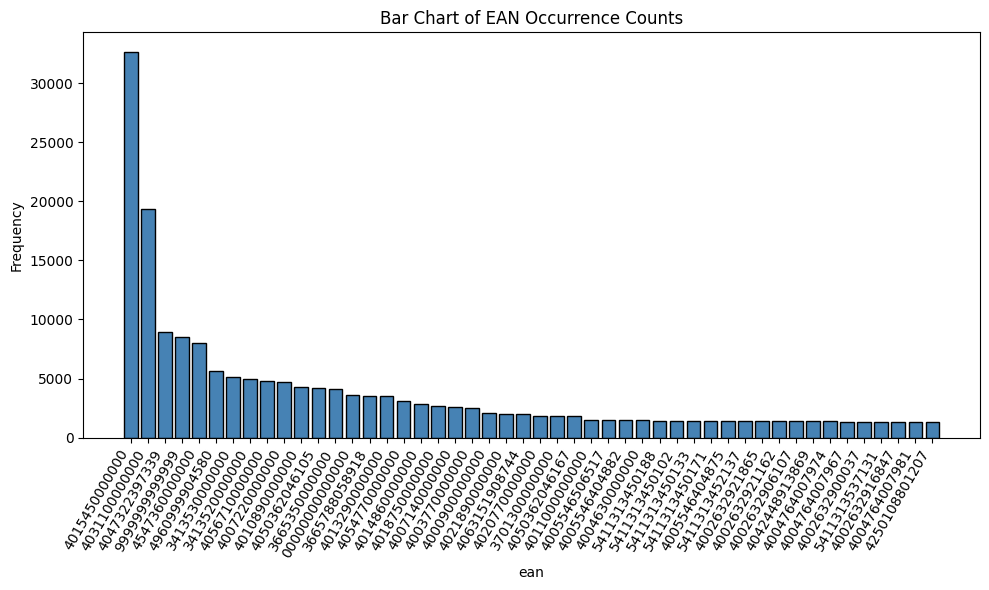

In [60]:
import matplotlib.pyplot as plt

# Query the data using DuckDB
result = duckdb.sql("""
SELECT
    ean,
    count(*) as c
FROM '/Users/max/Clients/simplesystem/code/analytics/data/offers.parquet'
GROUP BY ean
ORDER BY c DESC
""").df()

# Plot bar chart of top ean counts
plt.figure(figsize=(10,6))
top_counts = result.iloc[:50]
bars = plt.bar(top_counts['ean'].values, top_counts['c'].values, color='steelblue', edgecolor='black')
plt.xlabel('ean')
plt.ylabel('Frequency')
plt.title('Bar Chart of EAN Occurrence Counts')
plt.yscale('log')  # Optional: Log scale if heavy skew
plt.xticks(rotation=60, ha='right')  # Align x labels to the end of word (right side)
plt.tight_layout()  # Adjust layout so labels fit
plt.show()

In [61]:
top_counts[:20]

,ean,c
2,4015450000000,32656
3,4031100000000,19355
4,4047322397339,8951
5,9999999999999,8512
6,4547360000000,8017
7,4960999904580,5642
8,3413530000000,5154
9,3413520000000,5000
10,4056710000000,4817
11,4007220000000,4700


In [66]:
duckdb.sql("""
SELECT 
count(distinct catalog_version_id_b64),
count(distinct vendor_id_b64),
count(distinct article_number),
count(distinct name),
count(*),
FROM '/Users/max/Clients/simplesystem/code/analytics/data/offers.parquet'
WHERE ean = '4015450000000'
""")

┌────────────────────────────────────────┬───────────────────────────────┬────────────────────────────────┬────────────────────────┬──────────────┐
│ count(DISTINCT catalog_version_id_b64) │ count(DISTINCT vendor_id_b64) │ count(DISTINCT article_number) │ count(DISTINCT "name") │ count_star() │
│                 int64                  │             int64             │             int64              │         int64          │    int64     │
├────────────────────────────────────────┼───────────────────────────────┼────────────────────────────────┼────────────────────────┼──────────────┤
│                                      4 │                             1 │                           8164 │                   8164 │        32656 │
└────────────────────────────────────────┴───────────────────────────────┴────────────────────────────────┴────────────────────────┴──────────────┘

### Distinct articles count

How many distinct articles are there? That will tell us the upper bound of number of embeddings we will need.
This is an expensive query (takes about 11 minutes on my machine).

In [78]:
duckdb.sql("""
SELECT 
    format('{:t,}', 
        count(distinct row(article_number, vendor_id_b64, name, features, keywords, categoryPaths, description, ean, manufacturerName, manufacturerArticleNumber, manufacturerArticleType))
        ),
FROM '/Users/max/Clients/simplesystem/code/analytics/data/offers.parquet'
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ format('{:t,}', count(DISTINCT main."row"(article_number, vendor_id_b64, "name", features, keywords, categoryPaths, description, ean, manufacturerName, manufacturerArticleNumber, manufacturerArticleType))) │
│                                                                                                    varchar                                                                                                    │
├───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ 295,759,061                                                                                                                                                   

### Cardinality

Total count:

In [ ]:
duckdb.sql("""
SELECT 
    format('{:t,}', count(*)),
FROM '/Users/max/Clients/simplesystem/code/analytics/data/offers.parquet'
""")

┌───────────────────────────────┐
│ format('{:t,}', count_star()) │
│            varchar            │
├───────────────────────────────┤
│ 521,763,985                   │
└───────────────────────────────┘

In [84]:
duckdb.sql("""
SELECT 
    format('{:t,}', count(distinct article_number)) article_number,
    format('{:t,}', count(distinct vendor_id_b64)) vendor_id_b64,
    format('{:t,}', count(distinct name)) as name,
    format('{:t,}', count(distinct features)) features,
    format('{:t,}', count(distinct keywords)) keywords,
    format('{:t,}', count(distinct categoryPaths)) categoryPaths,
    format('{:t,}', count(distinct description)) description,
    format('{:t,}', count(distinct ean)) ean,
    format('{:t,}', count(distinct manufacturerName)) manufacturerName,
    format('{:t,}', count(distinct manufacturerArticleNumber)) manufacturerArticleNumber,
    format('{:t,}', count(distinct manufacturerArticleType)) manufacturerArticleType,
FROM '/Users/max/Clients/simplesystem/code/analytics/data/offers.parquet'
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌────────────────┬───────────────┬────────────┬─────────────┬────────────┬───────────────┬─────────────┬────────────┬──────────────────┬───────────────────────────┬─────────────────────────┐
│ article_number │ vendor_id_b64 │    name    │  features   │  keywords  │ categoryPaths │ description │    ean     │ manufacturerName │ manufacturerArticleNumber │ manufacturerArticleType │
│    varchar     │    varchar    │  varchar   │   varchar   │  varchar   │    varchar    │   varchar   │  varchar   │     varchar      │          varchar          │         varchar         │
├────────────────┼───────────────┼────────────┼─────────────┼────────────┼───────────────┼─────────────┼────────────┼──────────────────┼───────────────────────────┼─────────────────────────┤
│ 52,825,668     │ 738           │ 85,080,467 │ 140,247,209 │ 65,878,287 │ 3,365,780     │ 70,476,908  │ 14,975,577 │ 157,953          │ 26,434,147                │ 4,968,925               │
└────────────────┴───────────────┴───────────

In [82]:
duckdb.sql("""
SELECT 
    format('{:t,}', 
        count(distinct row(article_number, vendor_id_b64, ean, manufacturerArticleNumber, manufacturerArticleType))
        ),
FROM '/Users/max/Clients/simplesystem/code/analytics/data/offers.parquet'
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ format('{:t,}', count(DISTINCT main."row"(article_number, vendor_id_b64, ean, manufacturerArticleNumber, manufacturerArticleType))) │
│                                                               varchar                                                               │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ 131,727,582                                                                                                                         │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

In [96]:
def top_values(col):
    return duckdb.sql(f"""
    SELECT 
        {col},
        count(*) c,
    FROM '/Users/max/Clients/simplesystem/code/analytics/data/offers.parquet'
    GROUP BY {col}
    ORDER BY c DESC
    """)

#### Vendors

In [89]:
top_values('vendor_id_b64')

┌──────────────────────────┬──────────┐
│      vendor_id_b64       │    c     │
│         varchar          │  int64   │
├──────────────────────────┼──────────┤
│ 6jQN48ohRHuVZbLNnRQSCg== │ 42758015 │
│ +j3YfMbPQ8urt9d0YZWagA== │ 31280995 │
│ sJYNEAeYQAW/xS93y8Z4/Q== │ 30056902 │
│ ame4tZt8R/CS1R39iBKlBQ== │ 28211810 │
│ 2MgK2j6RQHapDfP9BwdSEQ== │ 23027293 │
│ 2GeKzY/vQ+SgTboLDs8U7A== │ 16593119 │
│ IWxdQbZKQvGwhNfjQZsiGQ== │ 15869190 │
│ FvYcxDa6SuCN3PehiKVxdg== │ 15852716 │
│ ZAS0UD4oRtS/pWRVk/i4ng== │ 13752476 │
│ WC3/Ql8ZQIG3KNzVCFOINQ== │ 12257784 │
│            ·             │        · │
│            ·             │        · │
│            ·             │        · │
│ 5ebK/6SwQGqaKxYOkIRGlQ== │        8 │
│ Wm12PLJCRUWuCZswySBLcg== │        7 │
│ o+X6vVOWSCq7WPydKs2RNQ== │        7 │
│ YFK1FT3ZTlevsI2iq4FZsA== │        7 │
│ zvcor0hXQaaIp0yNmSrM2A== │        5 │
│ WhG//9VGQseemjc28xGgCg== │        5 │
│ E6H3YjCBRVaxIqhrYvfOxQ== │        2 │
│ 5DLU7DH3RZ24xcVtKfwD/Q== │        2 │


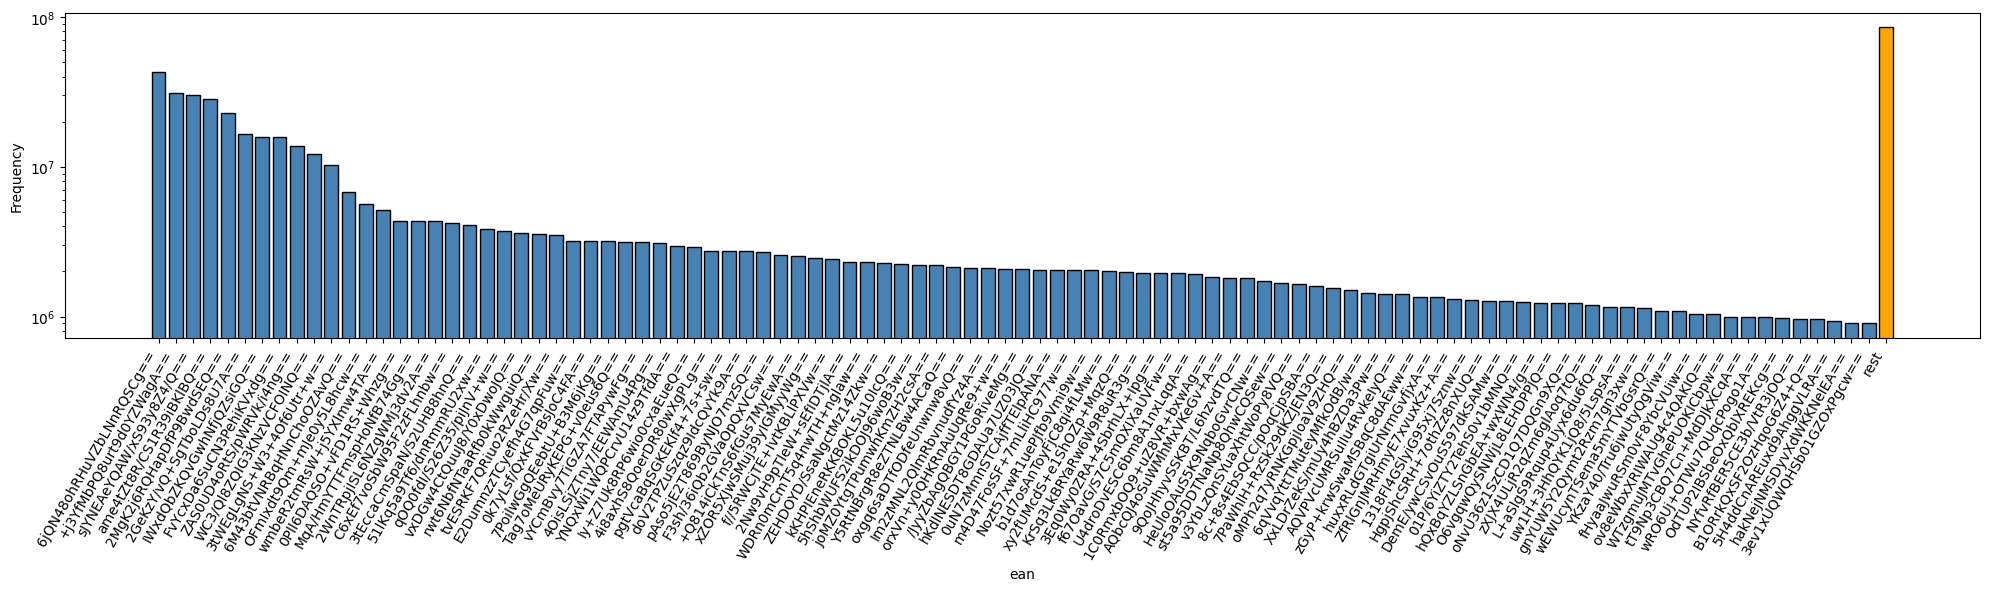

In [120]:
import matplotlib.pyplot as plt

# Query the data using DuckDB
result = top_values('vendor_id_b64')


# Plot bar chart of top ean counts
plt.figure(figsize=(20,6))
n = 100
top_counts = result.df().iloc[:n]
rest = result.df().iloc[n:].sum()
bars = plt.bar(top_counts['vendor_id_b64'].values, top_counts['c'].values, color='steelblue', edgecolor='black')
plt.bar('rest', rest['c'] if 'c' in rest else rest.iloc[1], color='orange', edgecolor='black')
plt.xlabel('ean')
plt.ylabel('Frequency')
plt.yscale('log')  # Optional: Log scale if heavy skew
plt.xticks(rotation=60, ha='right')  # Align x labels to the end of word (right side)
plt.tight_layout()  # Adjust layout so labels fit
plt.show()

#### Catalog version ids

In [99]:
result = top_values('catalog_version_id_b64')
result

┌──────────────────────────┬─────────┐
│  catalog_version_id_b64  │    c    │
│         varchar          │  int64  │
├──────────────────────────┼─────────┤
│ GMaRxapYS3qQdbjy28CZww== │ 1663653 │
│ qZlDAXnfStulESxfsHR4zQ== │ 1591748 │
│ b4X5jQO7QyWvACzDHiWUkg== │ 1352525 │
│ x7jhpm3LTR+74x+utSOlfQ== │ 1352525 │
│ 5Rcy11ZqT76kWHV6KLxpIw== │ 1344972 │
│ u6K8tUKJSAim9J4lRqHhQw== │ 1323702 │
│ pnN8a3LUQZeyiTWlmZUs2A== │ 1317803 │
│ 9YabmckpRECsLYC1hO4ldA== │ 1308276 │
│ hKFhgxXETJ+OTA7rW0jTQQ== │ 1273086 │
│ x3rOkVamQcGZHYkkhbKMqA== │ 1265393 │
│            ·             │       · │
│            ·             │       · │
│            ·             │       · │
│ bgXdlW3/TN6ZgnwuRFZaZw== │       1 │
│ nKhmMbPBSNC/EQC0/No8eA== │       1 │
│ w0MbhsWNRWihKHNwhvxvrg== │       1 │
│ yJgZLwygSWu6PUF4Uzx//A== │       1 │
│ QKYamiv7Qr+S8MlMIam8GQ== │       1 │
│ zpu9rFeTRT2ifWxSNlIkqQ== │       1 │
│ nXZQpidwTRqv/9QOo8xDvA== │       1 │
│ NNc6/H/oQBSPpc6C336XMA== │       1 │
│ 3lDSnNF3RamXl2FrkcMOVw=

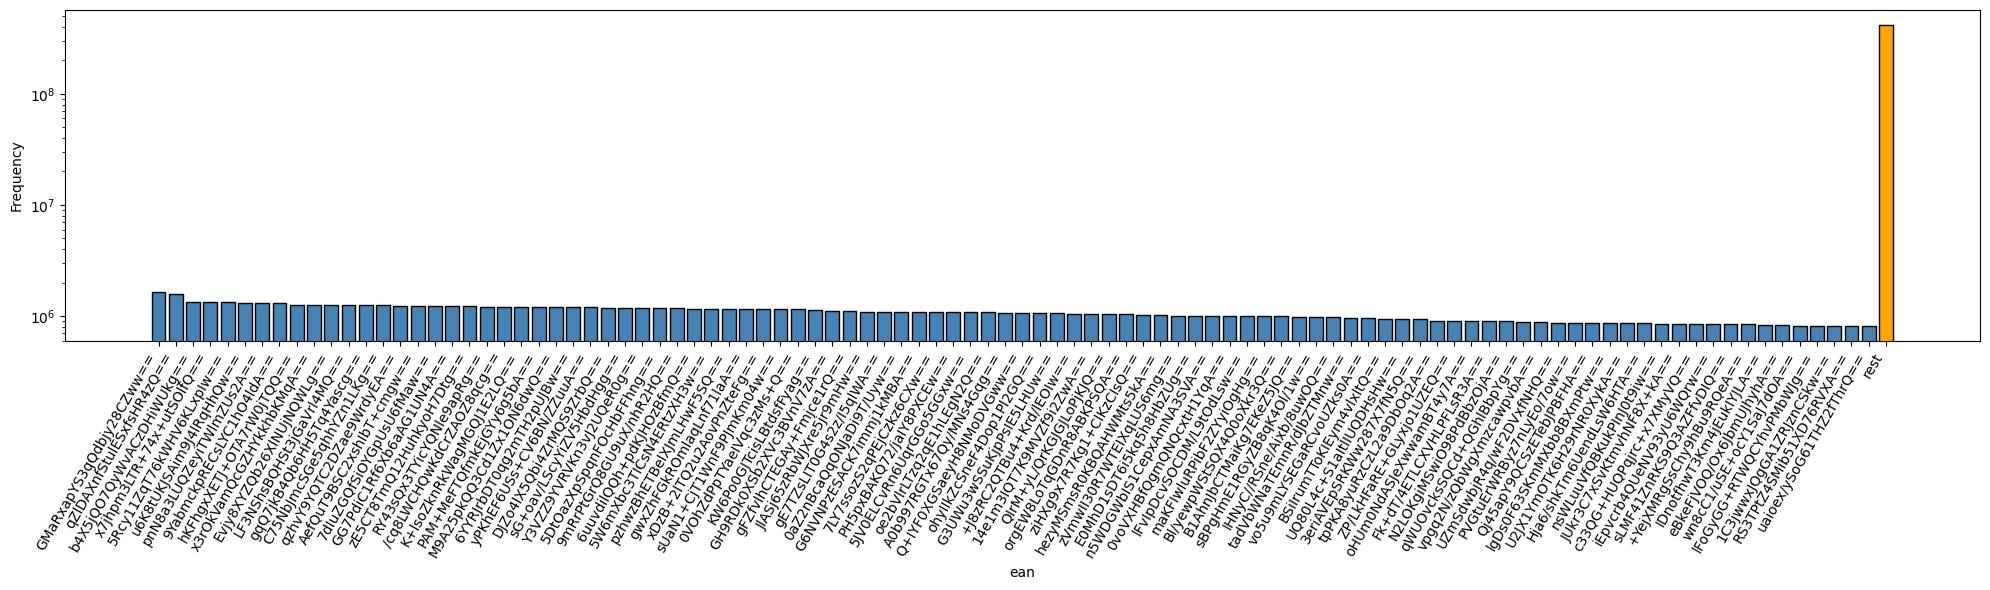

In [101]:
import matplotlib.pyplot as plt

# Plot bar chart of top ean counts
plt.figure(figsize=(20,6))
n = 100
top_counts = result.df().iloc[:n]
rest = result.df().iloc[n:].sum()
bars = plt.bar(top_counts['catalog_version_id_b64'].values, top_counts['c'].values, color='steelblue', edgecolor='black')
plt.bar('rest', rest['c'] if 'c' in rest else rest.iloc[1], color='orange', edgecolor='black')
plt.xlabel('ean')
plt.ylabel('Frequency')
plt.yscale('log')  # Optional: Log scale if heavy skew
plt.xticks(rotation=60, ha='right')  # Align x labels to the end of word (right side)
plt.tight_layout()  # Adjust layout so labels fit
plt.show()

#### Manufacturers

In [94]:
result = top_values('manufacturerName')
result

┌────────────────────────────┬──────────┐
│      manufacturerName      │    c     │
│          varchar           │  int64   │
├────────────────────────────┼──────────┤
│ Würth                      │ 67905843 │
│                            │ 17619557 │
│ GARANT                     │ 10982137 │
│ SMC                        │  9151936 │
│ Otto Ganter GmbH & Co. KG  │  5637000 │
│ Ceratizit Group            │  5114869 │
│ NORDWEST Handel AG         │  5100166 │
│ ISCAR                      │  4837050 │
│ HOLEX                      │  3655982 │
│ SMC Deutschland GmbH       │  3575442 │
│          ·                 │       ·  │
│          ·                 │       ·  │
│          ·                 │       ·  │
│ BARNSTEAD (INC THERMOLYNE) │     1495 │
│ VIVA                       │     1494 │
│ GESIPA®                    │     1494 │
│ L-SHOP-TEAM GMBH           │     1494 │
│ LEGO Icons                 │     1493 │
│ ILSI AMERICA               │     1493 │
│ KIRCHHOFF                  │    

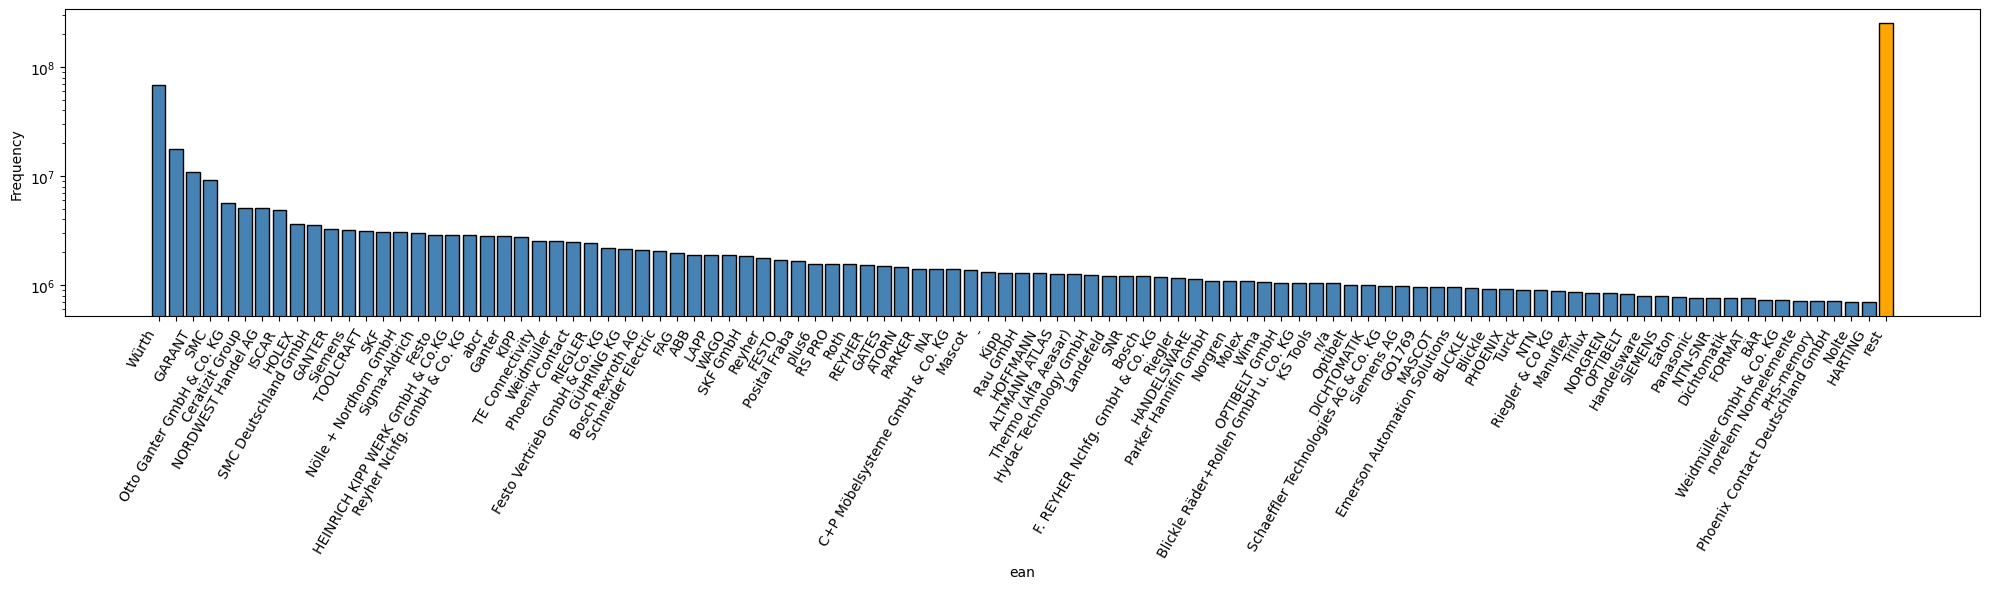

In [ ]:
import matplotlib.pyplot as plt

# Plot bar chart of top ean counts
plt.figure(figsize=(20,6))
n = 100
top_counts = result.df().iloc[:n]
rest = result.df().iloc[n:].sum()
bars = plt.bar(top_counts.iloc[:, 0].values, top_counts.iloc[:, 1].values, color='steelblue', edgecolor='black')
# Plot the 'rest' sum as a separate bar at the end
plt.bar('rest', rest['c'] if 'c' in rest else rest.iloc[1], color='orange', edgecolor='black')
plt.xlabel('ean')
plt.ylabel('Frequency')
plt.yscale('log')  # Optional: Log scale if heavy skew
plt.xticks(rotation=60, ha='right')  # Align x labels to the end of word (right side)
plt.tight_layout()  # Adjust layout so labels fit
plt.show()

#### Article types

In [140]:
result = top_values('manufacturerArticleType')
result

┌──────────────────────────────────────────┬───────────┐
│         manufacturerArticleType          │     c     │
│                 varchar                  │   int64   │
├──────────────────────────────────────────┼───────────┤
│                                          │ 489436725 │
│ norelem Normelemente GmbH & Co. KG       │    192892 │
│ HEINRICH KIPP WERK GmbH & Co. KG         │    179358 │
│ Norgren GmbH                             │    103254 │
│ Bosch Rexroth                            │     82536 │
│ Festo Vertrieb GmbH & Co. KG             │     44764 │
│ Einkaufsbüro Deutscher Eisenhändler GmbH │     38834 │
│                                          │     30921 │
│ VHM-Bohrer mit Kühlkanal                 │     28597 │
│ ÖLFLEX CLASSIC                           │     27073 │
│    ·                                     │         · │
│    ·                                     │         · │
│    ·                                     │         · │
│ LS-XRLA                      

### Text columns

In [5]:
def length_stats(col):
    return duckdb.sql(f"""
    SELECT
    unnest(map_entries(histogram(length({col}))), recursive:=true)
    FROM '/Users/max/Clients/simplesystem/code/analytics/data/offers.parquet'
    """)

#### Name

In [138]:
length_stats('name')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌───────┬─────────┐
│  key  │  value  │
│ int64 │ uint64  │
├───────┼─────────┤
│     1 │    2404 │
│     2 │    1522 │
│     3 │   37796 │
│     4 │  127719 │
│     5 │  246692 │
│     6 │  403550 │
│     7 │  572400 │
│     8 │ 1066641 │
│     9 │ 1070242 │
│    10 │ 1922148 │
│     · │     ·   │
│     · │     ·   │
│     · │     ·   │
│   121 │  193859 │
│   122 │  207079 │
│   123 │  168253 │
│   124 │  173825 │
│   125 │  175975 │
│   126 │  176118 │
│   127 │  187735 │
│   128 │  180881 │
│   129 │  169923 │
│   130 │ 2628316 │
├───────┴─────────┤
│    130 rows     │
│   (20 shown)    │
└─────────────────┘

In [137]:

duckdb.sql(f"""
SELECT
name
FROM '/Users/max/Clients/simplesystem/code/analytics/data/offers.parquet'
WHERE length(name) < 3
LIMIT 100
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌────────────┐
│    name    │
│  varchar   │
├────────────┤
│ 5          │
│ P4         │
│ P3         │
│ R3         │
│ R6         │
│ R8         │
│ 18         │
│ W2         │
│ W1         │
│ W0         │
│ ·          │
│ ·          │
│ ·          │
│ TW         │
│ F8         │
│ E5         │
│ E8         │
│ G5         │
│ G8         │
│ C5         │
│ C8         │
│ A8         │
│ A5         │
├────────────┤
│  100 rows  │
│ (20 shown) │
└────────────┘

In [27]:

duckdb.sql(f"""
SELECT
count(DISTINCT trim(lower(name)))
FROM '/Users/max/Clients/simplesystem/code/analytics/data/offers.parquet'
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌────────────────────────────────────────────┐
│ count(DISTINCT main."trim"(lower("name"))) │
│                   int64                    │
├────────────────────────────────────────────┤
│                                   84050341 │
└────────────────────────────────────────────┘

Storage needed for embedding all unique product names, in GB:

In [36]:
84_050_341 * 512 * 2 // 1_000_000_000

86

#### Description

In [87]:
length_stats('description')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────────┬──────────┐
│     key     │  value   │
│    int64    │  uint64  │
├─────────────┼──────────┤
│           0 │ 22427853 │
│           1 │   464331 │
│           2 │    47725 │
│           3 │    88951 │
│           4 │   441168 │
│           5 │    79769 │
│           6 │   746331 │
│           7 │   201956 │
│           8 │   206910 │
│           9 │   594919 │
│           · │        · │
│           · │        · │
│           · │        · │
│       10062 │        8 │
│       10063 │        1 │
│       10064 │        4 │
│       10065 │       28 │
│       10066 │        2 │
│       10067 │        2 │
│       10068 │       11 │
│       10069 │        3 │
│       10070 │        4 │
│       10071 │        4 │
├─────────────┴──────────┤
│ ? rows       2 columns │
│ (>9999 rows, 20 shown) │
└────────────────────────┘

In [88]:
result = duckdb.sql("""
    SELECT
    unnest(map_entries(histogram(length(description), equi_width_bins(0, 10071, 200, true))), recursive:=true)
    FROM '/Users/max/Clients/simplesystem/code/analytics/data/offers.parquet'
    """)

In [90]:
result

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────────────────┬──────────┐
│         key         │  value   │
│        int64        │  uint64  │
├─────────────────────┼──────────┤
│                  50 │ 91411095 │
│                 100 │ 67537268 │
│                 150 │ 40160426 │
│                 200 │ 26158044 │
│                 250 │ 22877131 │
│                 300 │ 24213095 │
│                 350 │ 19332676 │
│                 400 │ 20193986 │
│                 450 │ 18622399 │
│                 500 │ 17638391 │
│                  ·  │       ·  │
│                  ·  │       ·  │
│                  ·  │       ·  │
│                9700 │      414 │
│                9750 │      604 │
│                9800 │      919 │
│                9850 │      374 │
│                9900 │      333 │
│                9950 │      575 │
│               10000 │     1007 │
│               10050 │      554 │
│               10100 │      402 │
│ 9223372036854775807 │    20354 │
├─────────────────────┴──────────┤
│ 203 rows (20 shown

In [89]:
import matplotlib.pyplot as plt

# Plot bar chart of top ean counts
plt.figure(figsize=(20,6))
n = 200
top_counts = result.iloc[:n]
rest = result.iloc[n:].sum()
bars = plt.bar(top_counts.iloc[:, 0].values, top_counts.iloc[:, 1].values, color='steelblue', edgecolor='black')
# Plot the 'rest' sum as a separate bar at the end
plt.bar(n, rest.iloc[1], color='orange', edgecolor='black')
plt.xlabel('ean')
plt.ylabel('Frequency')
plt.yscale('log')  # Optional: Log scale if heavy skew
plt.xticks(rotation=60, ha='right')  # Align x labels to the end of word (right side)
plt.tight_layout()  # Adjust layout so labels fit
plt.show()

AttributeError: This relation does not contain a column by the name of 'iloc'

<Figure size 2000x600 with 0 Axes>

In [78]:
top_counts.iloc[:,0]

0      0
1      1
2      2
3      3
4      4
      ..
95    95
96    96
97    97
98    98
99    99
Name: key, Length: 100, dtype: int64

### Structs

#### Features

In [13]:
def struct_stats(col):
    return duckdb.sql(f"""
    SELECT
    unnest({col}, recursive:=true)
    FROM '/Users/max/Clients/simplesystem/code/analytics/data/offers.parquet'
    """)
struct_stats('features')

┌───────────────────────┬──────────────────────┬─────────┬─────────────────────────────────┬──────────────┐
│         name          │        values        │  unit   │           description           │ valueDetails │
│        varchar        │      varchar[]       │ varchar │             varchar             │   varchar    │
├───────────────────────┼──────────────────────┼─────────┼─────────────────────────────────┼──────────────┤
│ DEPTH GRO             │ [480.00]             │ mm      │ NULL                            │ NULL         │
│ Breite                │ [450]                │ mm      │ Breite 450 mm                   │ NULL         │
│ TRANSPORT TYPE        │ [Paketdienst]        │ NULL    │ NULL                            │ NULL         │
│ Eigengewicht          │ [3.34]               │ kg      │ Eigengewicht 3.34 kg            │ NULL         │
│ WIDTH GRO             │ [375.00]             │ mm      │ NULL                            │ NULL         │
│ HEIGHT GRO            │ [8

In [25]:

duckdb.sql(f"""
SELECT
count(DISTINCT name)
FROM (
SELECT
unnest(features).name as name
FROM '/Users/max/Clients/simplesystem/code/analytics/data/offers.parquet'
)
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌────────────────────────┐
│ count(DISTINCT "name") │
│         int64          │
├────────────────────────┤
│                 391586 │
└────────────────────────┘

In [26]:

duckdb.sql(f"""
SELECT
count(DISTINCT trim(lower(name)))
FROM (
SELECT
unnest(features).name as name
FROM '/Users/max/Clients/simplesystem/code/analytics/data/offers.parquet'
)
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌────────────────────────────────────────────┐
│ count(DISTINCT main."trim"(lower("name"))) │
│                   int64                    │
├────────────────────────────────────────────┤
│                                     384146 │
└────────────────────────────────────────────┘

In [6]:
length_stats('features')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌───────┬───────────┐
│  key  │   value   │
│ int64 │  uint64   │
├───────┼───────────┤
│     0 │ 164094892 │
│     1 │  35528490 │
│     2 │  20003098 │
│     3 │  17625868 │
│     4 │  21302841 │
│     5 │  18168639 │
│     6 │  23283678 │
│     7 │  22294522 │
│     8 │  18405748 │
│     9 │  15759572 │
│     · │         · │
│     · │         · │
│     · │         · │
│   161 │        30 │
│   163 │        17 │
│   164 │         2 │
│   165 │       150 │
│   166 │         9 │
│   167 │         8 │
│   169 │        12 │
│   170 │        32 │
│   171 │        92 │
│   187 │        15 │
├───────┴───────────┤
│     170 rows      │
│    (20 shown)     │
└───────────────────┘

#### Categories

In [48]:

duckdb.sql(f"""
SELECT
unnest(map_entries(histogram(length(categoryPaths))), recursive:=true)
FROM '/Users/max/Clients/simplesystem/code/analytics/data/offers.parquet'
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌───────┬───────────┐
│  key  │   value   │
│ int64 │  uint64   │
├───────┼───────────┤
│     0 │  24904110 │
│     1 │ 495681808 │
│     2 │    907630 │
│     3 │    165647 │
│     4 │     92662 │
│     5 │      7730 │
│     6 │      2162 │
│     7 │      1165 │
│     8 │       425 │
│     9 │        72 │
│     · │         · │
│     · │         · │
│     · │         · │
│    15 │        76 │
│    16 │         5 │
│    17 │       115 │
│    18 │        15 │
│    19 │        13 │
│    20 │       154 │
│    22 │         1 │
│    23 │         1 │
│    24 │         2 │
│    27 │         4 │
├───────┴───────────┤
│      25 rows      │
│    (20 shown)     │
└───────────────────┘

In [71]:

duckdb.sql(f"""
select (elements) as category, count(*) as c from (
SELECT
unnest(categoryPaths, recursive:=true)
FROM '/Users/max/Clients/simplesystem/code/analytics/data/offers.parquet'
)
GROUP BY category
ORDER BY c DESC
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬─────────┐
│                                                                                      category                                                                                      │    c    │
│                                                                                     varchar[]                                                                                      │  int64  │
├────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┼─────────┤
│ [LABORVERBRAUCHSMATERIAL UND GERÄTE, Chemikalien und Reagenzien, Diverse Chemikalien/Reagenzien, Diverse Chemikalien/Reagenzien]                                                   │ 4309053 │
│ [LABORCHEMIE]                    

## Export for index

In [1]:
import duckdb

duckdb.sql("""
COPY (
    SELECT
    DISTINCT
    name,
    ean,
    article_number,
    manufacturerArticleNumber,
    categoryPaths,
    manufacturerArticleType,
    manufacturerName,
    description
    FROM '/Users/max/Clients/simplesystem/data/offers.parquet'
) TO '/Users/max/Clients/simplesystem/data/offers_distinct.parquet'
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [9]:
import duckdb

duckdb.sql("""
COPY (
    SELECT
    *
    FROM '/Users/max/Clients/simplesystem/data/offers_distinct.parquet'
) TO '/Users/max/Clients/simplesystem/data/offers_distinct.parquet_dir'
(
    FORMAT PARQUET,
    FILE_SIZE_BYTES '256MB'
);
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [19]:
import duckdb

duckdb.sql("""
    SELECT
    *
    FROM '/Users/max/Clients/simplesystem/data/offers_distinct.parquet'
""")

┌──────────────────────────────────────────────────────────────────────────────┬───────────────┬────────────────────┬───────────────────────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬─────────────────────────┬──────────────────────────────┬──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

In [18]:
import duckdb

duckdb.sql("""
    SELECT
    count(*)
    FROM read_parquet('/Users/max/Clients/simplesystem/data/offers_distinct.parquet_dir/*')
""")

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│    159275274 │
└──────────────┘

## Merged dataset

In [23]:
import duckdb

duckdb.sql(f"""
SELECT
*
FROM '/Users/max/Clients/simplesystem/data/queries_offers_unlabeled.parquet'
""")

┌───────┬──────────────────────────────────────┬─────────────────────────────┬──────────────────┬────────────────────┬──────────────────────────────────┬──────────────────────────────────────┬──────────────────────────────────────┬─────────────────────────────────────────────┬──────────────────────────┬─────────────────┬──────────────────────────┬───────────────────────────────────────────────────────────────────────────────┬───────────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

### Annotations

In [25]:
import glob
import pandas as pd
filename = '/Users/max/Clients/max/ecomsearch/annotatorv3/outputs/2026-03-06/**/annotations*.jsonl'
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", None)
df = duckdb.sql(f"""
SELECT
filename,
row.query_term,
row.article_number,
row.name,
row.ean,
row.description,
row.query_id,
row.manufacturer_name,
TRY(json_extract_string(response.choices[1].message.content, 'label')) as label,
TRY(response.choices[1].message.reasoning) as reasoning
FROM '{filename}'
WHERE payload.model IN ('x-ai/grok-4.1-fast', 'grok-4-1-fast-reasoning')
AND filename >= '/Users/max/Clients/max/ecomsearch/annotatorv3/outputs/2026-03-06/17-27-02/'
""").df()
display(df.iloc[:10])

,filename,query_term,article_number,name,ean,description,query_id,manufacturer_name,label,reasoning
0,/Users/max/Clients/max/ecomsearch/annotatorv3/outputs/2026-03-06/17-27-02/annotations.jsonl,Kollegeblock pro office,254400430,Collegeblock A4 kariert weiß ohne Rand 80 Blatt/Block holzfrei,4036031755608,"Hochfeines Schreibpapier. Elementar chlorfrei gebleicht. Mit Spiralbindung und Randlinie. Mikroperforation zum leichten, sauberen Abtrennen. Holzfrei 70g/m². Block mit 80 Blatt.",4643411d-d3ca-5c95-a8d4-f9b0cc22ae7a,Pro/office,Exact,"The task is to classify the relevance of the product to the query using ESCI: Exact, Substitute, Complement, Irrelevant.\n\n\n## Evaluating product relevance \n- The task is to classify the product's relevance to a query using ESCI categories: Exact, Substitute, Complement, or Irrelevant."
1,/Users/max/Clients/max/ecomsearch/annotatorv3/outputs/2026-03-06/17-27-02/annotations.jsonl,plotter,902774,SIEM Leerschild 8WH8113-6AA05 für Plotter,4001869355887,"Beschriftungsschild, Flachbeschriftung, Klemmenbreite 12,2mm, Schnappbefestigung, weiß Reihenklemmen-Anschlusstechnik für diverse Industrieanwendungen und moderne Gebäudeinstallation von Siemens. Ganz gleich, ob Sie sich für den Schraub-, Zugfeder-, Push-in-oder Schnellanschluss entscheiden: Alle Anschlusstechniken sind frei untereinander kombinierbar. Das Beschriftungs- und Prüfzubehör ist standardisiert und übergreifend nutzbar. Mit den Reihenklemmen von SIEMENS können viele Anwendungen in Industrie,- Zweck- und Wohnungsbau realisiert werden. So haben Sie für jede Verbindung die passende Anschlusstechnik. Die Siemens Reihenklemmen zeichnen sich vor allem aus durch: 1. Dauerhaft sicherer Kontakt. 2. Leicht lösbarer Anschluss elektrischer Verbindungen wie Kabel und Leitungen. 3. Realisierung einer Vielzahl von Anwendungen. 4. Komfortable und einfache Montage- sowie Anschlusstechnik. 5. Umfangreiches und standardisiertes Zubehör. 6. Zuverlässige Sicherheit bei der Installation dank standardmäßigem Berührungsschutz. 7. Optimale Technik für Ihre Sicherheit - nur von Siemens.",463dab8a-a887-59b8-af78-f0b0c6534831,Siemens AG,Complement,"The task is to classify the relevance of the product to the query ""plotter"" using ESCI: Exact, Substitute, Complement, Irrelevant.\n\n\n## Evaluating Product Relevance \n- The task is to classify the product’s relevance to the query ""plotter"" using ESCI categories: Exact, Substitute, Complement, Irrelevant. \n- The product title is ""SIEM Leerschild 8WH8113-6AA05 für Plotter,"" indicating it’s specifically for a plotter. \n- The term ""für Plotter"" suggests the product is a component or accessory designed for plotters, likely a Complement. \n- Further analysis is needed to determine if it fits as an Exact match or Substitute, depending on its primary function."
2,/Users/max/Clients/max/ecomsearch/annotatorv3/outputs/2026-03-06/17-27-02/annotations.jsonl,plotter,0467539,Phoenix Contact Zubehör für Plotter CMS-P1-M/LBHZ,4017918948795,Art des Zubehörs/Ersatzteils sonstige<br />Zubehör<br /><br /> Kunststoff-Magazine für CMS-P1-Plotter. Zur Aufnahme von 20 Streifen leiterbezeichnung LBHZ,463dab8a-a887-59b8-af78-f0b0c6534831,Phoenix Contact,Complement,"The task is to classify the relevance of the product to the query ""plotter"" using ESCI: Exact, Substitute, Complement, Irrelevant.\n\n\n## Evaluating product relevance \n- Task is to classify the product Phoenix Contact Zubehör für Plotter CMS-P1-M/LBHZ for the query ""plotter"" using ESCI categories: Exact, Substitute, Complement, Irrelevant."
3,/Users/max/Clients/max/ecomsearch/annotatorv3/outputs/2026-03-06/17-27-02/annotations.jsonl,Briefumschlag DIN,GK40/180310,"Briefumschläge, DIN lang, ohne Fenster, selbstklebend, 100 Stück",4003928225414,in Kleinpackungen mit Innendruck selbstklebend oder mit Haftklebe-Streifen cellophaniert weiss VE-Inhalt (Stück): 25/100Formate: DIN lang &#61; 220 x 110 mm,4640301d-0d1b-5893-814d-978c79a89975,Eurokuvert,Exact,"The task is to cla

### Merge annotations with current query-offers dataset

In [33]:
duckdb.sql(f"""
    SELECT
    filename,
    row.*
    FROM '/Users/max/Clients/max/ecomsearch/annotatorv3/outputs/2026-03-06/**/annotations*.jsonl'
    WHERE payload.model IN ('x-ai/grok-4.1-fast', 'grok-4-1-fast-reasoning')
    AND filename >= '/Users/max/Clients/max/ecomsearch/annotatorv3/outputs/2026-03-06/17-27-02/'
""")

┌─────────────────────────────────────────────────────────────────────────────────────────────┬────────┬──────────────────────────────────────┬─────────────────────────┬──────────────────┬────────────────────┬──────────────────────────────────┬──────────────────────────────────────┬──────────────────────────────────────┬────────────────────────────────────────┬──────────────────────────┬────────────────┬──────────────────────────┬──────────────────────────────────────────────────────────────────────┬───────────────┬──────────────────────────────┬────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

In [41]:
duckdb.sql("SELECT count(*), count(distinct query_id), count(distinct offer_id_b64), count(distinct (query_term, offer_id_b64)) FROM '/Users/max/Clients/simplesystem/data/queries_offers_unlabeled.parquet'")

┌──────────────┬──────────────────────────┬──────────────────────────────┬──────────────────────────────────────────────────────┐
│ count_star() │ count(DISTINCT query_id) │ count(DISTINCT offer_id_b64) │ count(DISTINCT main."row"(query_term, offer_id_b64)) │
│    int64     │          int64           │            int64             │                        int64                         │
├──────────────┼──────────────────────────┼──────────────────────────────┼──────────────────────────────────────────────────────┤
│      1975954 │                    78336 │                      1040044 │                                              1423838 │
└──────────────┴──────────────────────────┴──────────────────────────────┴──────────────────────────────────────────────────────┘

In [99]:
duckdb.sql("""
SELECT
count(*)
FROM '/Users/max/Clients/simplesystem/data/queries_offers_labeled.parquet'
""")

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│       204206 │
└──────────────┘

In [97]:
duckdb.sql("""
SELECT avg(c) FROM (
SELECT
query_id,
count(distinct offer_id_b64) as c
FROM '/Users/max/Clients/simplesystem/data/queries_offers_labeled.parquet'
GROUP BY query_id
)
""")


┌───────────────────┐
│      avg(c)       │
│      double       │
├───────────────────┤
│ 9.684894474745079 │
└───────────────────┘

In [112]:
duckdb.sql("""
COPY (
    WITH a AS (
        SELECT
        row.*,
        TRY(json_extract_string(response.choices[1].message.content, 'label')) as label,
        TRY(response.choices[1].message.reasoning) as reasoning
        FROM '/Users/max/Clients/max/ecomsearch/annotatorv3/outputs/2026-03-06/**/annotations*.jsonl'
        WHERE payload.model IN ('x-ai/grok-4.1-fast', 'grok-4-1-fast-reasoning')
        AND filename >= '/Users/max/Clients/max/ecomsearch/annotatorv3/outputs/2026-03-06/17-27-02/'
        AND label <> '' AND label IS NOT NULL
    ),
    d AS (
        SELECT
        *
        FROM '/Users/max/Clients/simplesystem/data/queries_offers_unlabeled.parquet'
        WHERE TRIM(query_term) <> ''
    ),
    merged AS (
        SELECT
        d.*,
        a.label,
        ROW_NUMBER() OVER (PARTITION BY d.query_term, d.offer_id_b64) AS _rn
        FROM d
        INNER JOIN a
        ON d.query_id = a.query_id
        AND d.query_term = a.query_term
        AND d.offer_id_b64 = a.offer_id_b64
        AND d.description = a.description
    )
    SELECT * EXCLUDE _rn FROM merged WHERE _rn = 1
) TO '/Users/max/Clients/simplesystem/data/queries_offers_labeled.parquet'
(FORMAT PARQUET, COMPRESSION ZSTD, ROW_GROUP_SIZE 250000)
""")
df = duckdb.sql("SELECT * FROM '/Users/max/Clients/simplesystem/data/queries_offers_labeled.parquet'").df()
df.sample(10)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

example_id                              query_id           query_term  \
161304      279261  241d72ac-39fa-5684-91fe-28e46e030b67         waffeleisen    
177693      209331  1b199292-1597-5927-b9d2-e7fda9347661     multimeter fluke   
54601       557527  480e9e98-d8f4-5412-b421-97f41730e783            Jabra BIZ   
58561       622937  5036d3c9-d431-5429-9774-d3db221b0f97              Magnete   
39903      1742496  e21da052-bba4-5d86-84ea-717377d8d040         verlängerung   
13789       375571  30ba2a1a-8d04-5d7b-8abe-e8747b7725fe  bosch akkuschrauber   
15015      1681934  da378d4d-3bc8-59c4-85e7-6e7bdcae049d        4015394017288   
20522       981833  7fc4a52f-7fef-5f70-a7a9-c0750b5938c5        4010220030752   
154787      329448  2aedf9f2-7c55-5957-a6c4-0403570148d1     schütz 24v 3s 1ö   
33180      1031102  85d988ca-ebc9-5026-8d99-c0e57494032d               Ordner   

       browser_language geoip_country_code                         timestamp  \
161304               de                 DE  2026-02-11T08:21:14.618000+01:00   
177693               de                 DE  2026-02-26T15:01:35.657000+01:00   
54601             de-DE                 DE  2026-02-25T12:21:12.337000+01:00   
58561                de                 DE  2026-02-04T10:48:08.541000+01:00   
39903                de                 DE  2026-02-11T13:24:10.132000+01:00   
13789             de-DE                 DE  2026-02-09T13:25:05.821000+01:00   
15015             de-DE                 DE  2026-02-05T15:49:14.096000+01:00   
20522                de                 DE  2026-02-18T13:59:24.192000+01:00   
154787            de-DE                 DE  2026-02-18T13:13:01.513000+01:00   
33180                de                 DE  2026-02-25T09:06:38.030000+01:00   

                                  session_id  \
161304  019c4b8d-87c9-7768-b050-38c29154ef14   
177693  019c999e-2899-7ef8-b430-53418d8a4982   
54601   019c9485-e742-7c3a-b480-d6a86f219816   
58561   019c27ff-8ca4-77b9-99ad-3b1bb6b88c30   
39903   019c4c9c-3e3a-7788-be5c-2115e680362d   
13789   019c4218-e51b-7103-9b74-6ced3b4defa0   
15015   019c2e46-fd3c-7f39-b614-3e45ffda82df   
20522   019c70b2-70b6-7a1b-88f7-eeea2ca06b1f   
154787  019c70a6-3a2b-776b-8625-1a083e246268   
33180   019c93d4-a52f-73af-9506-3ef185e97dd5   

                                     user_id  \
161304  7a8199a0-6a0e-4e63-ab8c-ccb819c1cf61   
177693  b7d560a0-36f6-4e49-b426-4d1aa18a0c05   
54601   67f46751-dcef-44a3-871a-61e5014bb506   
58561   ee3b49d2-9f38-4af8-8a3b-b2a90d01390e   
39903   f7d80070-163a-4b3e-bcc9-db4b67d7dc84   
13789   66220f14-0c30-47f3-9f2c-dbd390db6d7b   
15015   7b282108-af36-4f61-a686-350eec5182ff   
20522   59a113b7-049a-4199-94f0-335b7c316650   
154787  8461b4f3-ac04-46d6-9c5b-f48c5752e69c   
33180   6832e3f1-9164-4e03-a938-2f9a43bd2ea2   

                                          item_id             vendor_id_b64  \
161304          5gxdLdx67xY0FwQ4BZijy4:MzExOTAwNA  uw1H+3HhQYK1jQ8/5LspsA==   
177693        2cLGV40CehdX3ABE7tAo6x:RkxVS0UgMjg3  VgiXQU7RQi6seRsHYmaStw==   
54601      53Ju9zQzDreORH6bJGxdfX:R00wMS8zMzg2NjA  pgtVcaBqSGKEKlf4+7s+sw==   
58561      53Ju9zQzDreORH6bJGxdfX:R00wMS8xNjM5MTI  pgtVcaBqSGKEKlf4+7s+sw==   
39903   2cLGV40CehdX3ABE7tAo6x:RVQgNDUtMjg5LTIyNA  VgiXQU7RQi6seRsHYmaStw==   
13789         689fhRqiQRiG0367yBgQXH:NDk3ODUwMDAw  yXahu348SgqlFu9VUMG+Fw==   
15015           6hgS1TOmz0GaSXnXNdVKGU:Mjg4MDU2Mg  3Eq0Wy0ZRA+4SbrhLX+Ipg==   
20522         3tX0MSIg3tzl0aPGnMfbDb:ODQ0ODkxIDIw  f//5RWCjTE+IvtKBLlPXVw==   
154787          2gRGzwjynbDkqnoBffXspH:MDc5NjMzNQ  WDRn0mCmT5q4nwTH+nglaw==   
33180       70700wmcxJOoVZQV5suWke:TEVJMTAxMDU0NQ  5g7NmI0XSO2gqamftljQjA==   

       article_number              offer_id_b64  \
161304        3119004  SUQvgB5+SkSVCGJs1eTAxA==   
177693      FLUKE 287  FgcIO59oQH6B3DoMwV4+2g==   
54601     GM01/338660  owBz2hnlSqytwtJCjIuOXw==   
58561     GM01/163912  uUOCOZyNTXOHdF8/qHkLeQ==   
39903   ET 45-289-224  e/0UQ1y+TjGmDIDIBP/UYQ==   
1

In [114]:
df.shape

(204182, 20)

In [115]:
df.label.fillna('-').value_counts()

label
Exact         164199
Complement     14643
Irrelevant     13665
Substitute     11675
Name: count, dtype: int64

In [116]:
df.query_id.unique().size

21083

In [117]:
df.query_term.unique().size

18068

In [118]:
df.label.fillna('-').value_counts() / df.query_term.unique().size

label
Exact         9.087835
Complement    0.810438
Irrelevant    0.756309
Substitute    0.646170
Name: count, dtype: float64

## Finished dataset ready for training

In [14]:
import duckdb

duckdb.sql(f"""
SELECT
*
FROM '/Users/max/Clients/simplesystem/data/queries_offers_labeled.parquet'
""")

┌────────────┬──────────────────────────────────────┬──────────────────────────────────────────────┬──────────────────┬────────────────────┬──────────────────────────────────┬──────────────────────────────────────┬──────────────────────────────────────┬─────────────────────────────────────────────┬──────────────────────────┬─────────────────┬──────────────────────────┬────────────────────────────────────────────────────────────────────────────────────────┬───────────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

### Dataset stats

In [2]:
import duckdb

duckdb.sql(f"""
WITH counts AS (
    SELECT
    query_id,
    sum(label == 'Exact') pos,
    sum(label <> 'Exact') neg,
    FROM '/Users/max/Clients/simplesystem/data/queries_offers_labeled.parquet'
    GROUP BY 1
)
SELECT
quantile_disc(pos, 0.1),
quantile_disc(pos, 0.5),
quantile_disc(pos, 0.9),
quantile_disc(neg, 0.1),
quantile_disc(neg, 0.5),
quantile_disc(neg, 0.9),
quantile_disc(neg, 0.99),
sum(pos = 0),
sum(neg = 0),
sum(1)
FROM counts
""")

┌─────────────────────────┬─────────────────────────┬─────────────────────────┬─────────────────────────┬─────────────────────────┬─────────────────────────┬──────────────────────────┬────────────────┬────────────────┬────────┐
│ quantile_disc(pos, 0.1) │ quantile_disc(pos, 0.5) │ quantile_disc(pos, 0.9) │ quantile_disc(neg, 0.1) │ quantile_disc(neg, 0.5) │ quantile_disc(neg, 0.9) │ quantile_disc(neg, 0.99) │ sum((pos = 0)) │ sum((neg = 0)) │ sum(1) │
│         int128          │         int128          │         int128          │         int128          │         int128          │         int128          │          int128          │     int128     │     int128     │ int128 │
├─────────────────────────┼─────────────────────────┼─────────────────────────┼─────────────────────────┼─────────────────────────┼─────────────────────────┼──────────────────────────┼────────────────┼────────────────┼────────┤
│                       1 │                       5 │                      20 │         

- remove queries with pos = 0

In [41]:
import duckdb

duckdb.sql(f"""
WITH ds AS (SELECT * FROM '/Users/max/Clients/simplesystem/data/queries_offers_labeled.parquet')
SELECT
query_term,
name,
label
FROM ds
WHERE query_id IN (
    SELECT * FROM (SELECT distinct query_id FROM ds) USING SAMPLE reservoir(1 ROWS)
)
ORDER BY query_id
""")

┌────────────┬──────────────────────────────────────────────────────────────────────────────────────────────────┬─────────┐
│ query_term │                                               name                                               │  label  │
│  varchar   │                                             varchar                                              │ varchar │
├────────────┼──────────────────────────────────────────────────────────────────────────────────────────────────┼─────────┤
│ 362-555    │ PHS-memory 8GB RAM Speicher für BIOSTAR Racing B460GTQ DDR4 UDIMM 3200MHz PC4-25600-U (SP362555) │ Exact   │
│ 362-555    │ SYLL LED-Hallenleuchte Granit G2 IP65 165W 26400lm 840 55°                                       │ Exact   │
└────────────┴──────────────────────────────────────────────────────────────────────────────────────────────────┴─────────┘

how many offers have different ids but same name? 7%

In [8]:
import duckdb

duckdb.sql(f"""
WITH ds AS (SELECT * FROM '/Users/max/Clients/simplesystem/data/queries_offers_labeled.parquet'),
stats AS (
    SELECT
    name,
    count(distinct offer_id_b64) as c
    FROM ds
    group by 1
)
SELECT
sum(c = 1),
sum(c = 2),
sum(c = 3),
sum(c > 3),
sum(c > 1),
sum(1),
FROM stats
""")

┌──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬────────┐
│ sum((c = 1)) │ sum((c = 2)) │ sum((c = 3)) │ sum((c > 3)) │ sum((c > 1)) │ sum(1) │
│    int128    │    int128    │    int128    │    int128    │    int128    │ int128 │
├──────────────┼──────────────┼──────────────┼──────────────┼──────────────┼────────┤
│       149338 │         8324 │         1562 │         1384 │        11270 │ 160608 │
└──────────────┴──────────────┴──────────────┴──────────────┴──────────────┴────────┘

How many queries have at least N positives?

In [28]:
import duckdb

duckdb.sql(f"""
WITH counts AS (
    SELECT
    query_id,
    sum(label == 'Exact') pos,
    sum(label <> 'Exact') neg,
    sum(label = 'Irrelevant') hard_neg,
    FROM '/Users/max/Clients/simplesystem/data/queries_offers_labeled.parquet'
    GROUP BY 1
)
SELECT
sum(pos >= 2),
sum(pos >= 5),
sum(neg >= 2),
sum(neg >= 5),
sum(hard_neg >= 2),
sum(hard_neg >= 5),
sum(1)
FROM counts
""")

┌─────────────────┬─────────────────┬─────────────────┬─────────────────┬──────────────────────┬──────────────────────┬────────┐
│ sum((pos >= 2)) │ sum((pos >= 5)) │ sum((neg >= 2)) │ sum((neg >= 5)) │ sum((hard_neg >= 2)) │ sum((hard_neg >= 5)) │ sum(1) │
│     int128      │     int128      │     int128      │     int128      │        int128        │        int128        │ int128 │
├─────────────────┼─────────────────┼─────────────────┼─────────────────┼──────────────────────┼──────────────────────┼────────┤
│           16201 │           10576 │            5604 │            2649 │                 2139 │                  890 │  21083 │
└─────────────────┴─────────────────┴─────────────────┴─────────────────┴──────────────────────┴──────────────────────┴────────┘

Look at some of those queries:

In [31]:
import duckdb

duckdb.sql(f"""
WITH counts AS (
    SELECT
    query_id,
    sum(label = 'Exact') pos,
    sum(label <> 'Exact') neg,
    sum(label = 'Irrelevant') hard_neg,
    FROM '/Users/max/Clients/simplesystem/data/queries_offers_labeled.parquet'
    GROUP BY 1
)
SELECT
query_term,
name,
label
FROM '/Users/max/Clients/simplesystem/data/queries_offers_labeled.parquet'
WHERE query_id IN
(SELECT * FROM (SELECT query_id FROM counts WHERE pos >= 2 and hard_neg >= 2) USING SAMPLE reservoir(1 ROWS))
ORDER BY query_id

""")

┌───────────────┬─────────────────────────────────────────────────────────────────────────────┬────────────┐
│  query_term   │                                    name                                     │   label    │
│    varchar    │                                   varchar                                   │  varchar   │
├───────────────┼─────────────────────────────────────────────────────────────────────────────┼────────────┤
│ Melitta 202 S │ Melitta Prof. Coffee Pyramidenfilterpapier Pa SF 202 S (VE100)              │ Exact      │
│ Melitta 202 S │ Melitta SDA Pyramidenfilter 202 S (VE100)                                   │ Exact      │
│ Melitta 202 S │ Melitta SDA Kaffee/Espressoautomat CaffeoSoloPerfecMilk E 957-203 si        │ Substitute │
│ Melitta 202 S │ Melitta SDA Glaskanne f.M510 AromaExcSteel Typ 200 sw-eds                   │ Irrelevant │
│ Melitta 202 S │ Melitta Prof. Coffee Edelstahlkanne 2,2 l Ka-EST M 220 16589 eds            │ Irrelevant │
│ Melitta 202 S │ M

In [38]:
import duckdb

duckdb.sql(f"""
WITH res AS (SELECT * FROM '/Users/max/Clients/simplesystem/data/eval_result.parquet'),
ds AS (SELECT * FROM '/Users/max/Clients/simplesystem/data/queries_offers_eval.parquet')
SELECT
* from res

""")

┌────────────┬──────────────────────────────────────┬──────────────────────────┬────────────┬───────────────┐
│ row_number │               query_id               │       offer_id_b64       │   label    │  pair_score   │
│   int64    │               varchar                │         varchar          │  varchar   │     float     │
├────────────┼──────────────────────────────────────┼──────────────────────────┼────────────┼───────────────┤
│          0 │ 84d863c7-2750-5d3c-9823-633b3cdab966 │ EA1eqDcYTlykk2inNykgQg== │ Exact      │   0.021286398 │
│          1 │ 4673933d-bb6c-5c40-a151-01307cfc97a0 │ iU9aDji9RHW6CqjfB88H6w== │ Irrelevant │ -0.0077750846 │
│          2 │ 1099a314-29f7-5817-84c7-dfdd134f26c7 │ DNYxWlGuQYCLSB4mn4igHA== │ Exact      │    0.21721998 │
│          3 │ 8b8e14bf-30e2-59fe-95b4-b9b4d13e3b91 │ pO05BOXMQ0ezbHe81SojyQ== │ Complement │  -0.012172762 │
│          4 │ 51a3c589-4987-595d-89b0-da11e6e707de │ z+977QLWQ1CONSawY1m8/w== │ Exact      │    0.15141793 │
│         

In [40]:
import duckdb

duckdb.sql(f"""
WITH res AS (SELECT * FROM '/Users/max/Clients/simplesystem/data/eval_result.parquet'),
ds AS (SELECT * FROM '/Users/max/Clients/simplesystem/data/queries_offers_eval.parquet')
SELECT
query_term,
name,
res.label,
pair_score
FROM res
INNER JOIN ds ON res.query_id = ds.query_id
AND res.offer_id_b64 = ds.offer_id_b64

""")

┌───────────────────────┬──────────────────────────────────────────────────────────────────────────────────────────────────┬────────────┬───────────────┐
│      query_term       │                                               name                                               │   label    │  pair_score   │
│        varchar        │                                             varchar                                              │  varchar   │     float     │
├───────────────────────┼──────────────────────────────────────────────────────────────────────────────────────────────────┼────────────┼───────────────┤
│ 203054                │ HOLEX Pro Steel VHM-Schruppfräser HPC, TiAlN, ⌀ DC: 14mm                                         │ Exact      │   0.021286398 │
│ 67001674              │ 67001600 Sp.-Handrad 950                                                                         │ Irrelevant │ -0.0077750846 │
│ Bosch Schlagschrauber │ Bosch Schlagschrauber Bürstenloser Gleichstrommoto

### Let's build a train/test split

Let's have a look at the original dataset:

In [20]:
import duckdb

con = duckdb.connect()

# Utility function to show stats
def show_stats(ds, query_id_field):
    duckdb.sql(f"""
    WITH stats AS (
        SELECT
        {query_id_field},
        count(*) as n,
        sum(label = 'Exact') as n_pos,
        sum(label = 'Irrelevant') as n_neg,
        sum(label = 'Substitute') as n_sub,
        sum(label = 'Complement') as n_comp,
        FROM ds GROUP BY 1
        ORDER BY 1
    )
    SELECT
        (SELECT count(*) FROM ds) AS rows,
        count(*) AS queries,
        avg(n), min(n), max(n), sum(n),
        avg(n_pos), min(n_pos), max(n_pos), sum(n_pos),
        avg(n_neg), min(n_neg), max(n_neg), sum(n_neg),
        avg(n_sub), min(n_sub), max(n_sub), sum(n_sub),
        avg(n_comp), min(n_comp), max(n_comp), sum(n_comp),
    FROM stats
    """).show()


con.execute("CREATE TABLE ds AS SELECT * FROM '/Users/max/Clients/simplesystem/data/queries_offers_labeled.parquet'")
con.sql(f""" SELECT * FROM ds """).show()
show_stats(con.sql(f""" SELECT * FROM ds """).df(), 'query_id')

┌────────────┬──────────────────────────────────────┬──────────────────────────────────────────────┬──────────────────┬────────────────────┬──────────────────────────────────┬──────────────────────────────────────┬──────────────────────────────────────┬─────────────────────────────────────────────┬──────────────────────────┬─────────────────┬──────────────────────────┬────────────────────────────────────────────────────────────────────────────────────────┬───────────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

As we can see above, we have queries with 0 positive examples, other with 0 negative examples. Some have many examples, some only 1.

To create a more balanced dataset that contains more useful signals, we take a series of measures:

1. Normalize `query_norm` and group examples into queries based on that
2. De-duplicate examples based on `query_norm` and `name_norm`
3. Take at most 20 examples per query per label (e.g. <= 20 Exact, <= 20 Substitute, etc.)
4. Only use queries that have at least 5 positive examples; drop the others
5. Split into train and test sets based on `query_norm`
6. Remove examples from train that have `name_norm` in test
7. For queries that have fewer than 10 negative examples, add synthetic ones by sampling offers from other queries from the same split
8. Add `query_id` and `offer_id` based on the unique `query_norm` and `name_norm` values



In [21]:
from tqdm.notebook import tqdm
import pandas as pd
import duckdb

MAX_EXAMPLES_PER_LABEL = 20
MIN_POSITIVES_PER_QUERY = 5
MIN_NEGATIVES_PER_QUERY = 10
TEST_QUERIES = 400

ds = con.sql("""
    SELECT
    DISTINCT
    trim(lower(query_term)) as query_norm,
    trim(lower(name)) as name_norm,
    query_term, name, ean, article_number, category_paths, description, manufacturer_name, manufacturer_article_number, manufacturer_article_type,
    label
    FROM '/Users/max/Clients/simplesystem/data/queries_offers_labeled.parquet'
    ORDER BY example_id
""").df()
ds = ds.drop_duplicates(['query_norm', 'name_norm'])


def filter_ds(ds):
    ds_clean = []
    for _, group in tqdm(ds.groupby('query_norm')):
        pos = group.query('label == "Exact"')
        n_pos = len(pos)
        if n_pos < MIN_POSITIVES_PER_QUERY:
            continue
        ds_clean.append(pos.iloc[:MAX_EXAMPLES_PER_LABEL])
        ds_clean.append(group.query('label == "Substitute"').iloc[:MAX_EXAMPLES_PER_LABEL])
        ds_clean.append(group.query('label == "Complement"').iloc[:MAX_EXAMPLES_PER_LABEL])
        ds_clean.append(group.query('label == "Irrelevant"').iloc[:MAX_EXAMPLES_PER_LABEL])

    return pd.concat(ds_clean)

ds_clean = filter_ds(ds)
query_norms = ds_clean.drop_duplicates('query_norm')['query_norm'].sample(frac=1.0, random_state=41)
ds_test_raw = ds_clean[ds_clean['query_norm'].isin(query_norms[:TEST_QUERIES])].assign(split='test')
print('ds_test_raw')
show_stats(ds_test_raw, 'query_norm')
ds_train_raw = ds_clean[ds_clean['query_norm'].isin(query_norms[TEST_QUERIES:])].assign(split='train')
print('ds_train_raw')
show_stats(ds_train_raw, 'query_norm')
ds_train_raw = ds_train_raw[~ds_train_raw['name_norm'].isin(ds_test_raw['name_norm'])]
ds_train_raw = filter_ds(ds_train_raw)
print('ds_train_raw after removing offers that are in test')
show_stats(ds_train_raw, 'query_norm')


  0%|          | 0/16281 [00:00<?, ?it/s]

ds_test_raw
┌───────┬─────────┬─────────┬────────┬────────┬────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬─────────────┬─────────────┬─────────────┬─────────────┐
│ rows  │ queries │ avg(n)  │ min(n) │ max(n) │ sum(n) │ avg(n_pos) │ min(n_pos) │ max(n_pos) │ sum(n_pos) │ avg(n_neg) │ min(n_neg) │ max(n_neg) │ sum(n_neg) │ avg(n_sub) │ min(n_sub) │ max(n_sub) │ sum(n_sub) │ avg(n_comp) │ min(n_comp) │ max(n_comp) │ sum(n_comp) │
│ int64 │  int64  │ double  │ int64  │ int64  │ int128 │   double   │   int128   │   int128   │   int128   │   double   │   int128   │   int128   │   int128   │   double   │   int128   │   int128   │   int128   │   double    │   int128    │   int128    │   int128    │
├───────┼─────────┼─────────┼────────┼────────┼────────┼────────────┼────────────┼────────────┼────────────┼────────────┼────────────┼────────────┼────────────┼────────────┼────────

  0%|          | 0/7335 [00:00<?, ?it/s]

ds_train_raw after removing offers that are in test
┌────────┬─────────┬───────────────────┬────────┬────────┬────────┬────────────────────┬────────────┬────────────┬────────────┬────────────────────┬────────────┬────────────┬────────────┬────────────────────┬────────────┬────────────┬────────────┬────────────────────┬─────────────┬─────────────┬─────────────┐
│  rows  │ queries │      avg(n)       │ min(n) │ max(n) │ sum(n) │     avg(n_pos)     │ min(n_pos) │ max(n_pos) │ sum(n_pos) │     avg(n_neg)     │ min(n_neg) │ max(n_neg) │ sum(n_neg) │     avg(n_sub)     │ min(n_sub) │ max(n_sub) │ sum(n_sub) │    avg(n_comp)     │ min(n_comp) │ max(n_comp) │ sum(n_comp) │
│ int64  │  int64  │      double       │ int64  │ int64  │ int128 │       double       │   int128   │   int128   │   int128   │       double       │   int128   │   int128   │   int128   │       double       │   int128   │   int128   │   int128   │       double       │   int128    │   int128    │   int128    │
├────────┼─────

In [31]:

def sample_extra_negs(ds):
    offers_df = ds.drop_duplicates(['query_norm', 'name']).sample(frac=1.0, random_state=40)
    extra_negs = []
    idx_from = 0
    for query_norm, group in tqdm(ds.groupby('query_norm')):
        neg = group.query('label == "Irrelevant"')
        n_neg = len(neg)
        if n_neg >= MIN_NEGATIVES_PER_QUERY:
            continue
        missing = int(MIN_NEGATIVES_PER_QUERY - n_neg)
        idx_to = idx_from + missing
        x = offers_df.iloc[idx_from:idx_to].copy()
        idx_from = idx_to
        x = x[x['query_norm'] != query_norm]
        while len(x) < missing:
            idx_to = idx_from + 1
            x_ = offers_df.iloc[idx_from:idx_to].copy()
            x_ = x_[x_['query_norm'] != query_norm]
            if (len(x_) > 0):
                x = pd.concat([x, x_])
            idx_from = idx_to
        x['query_norm'] = query_norm
        x['query_term'] = group.iloc[0]['query_term']
        x['label'] = 'Irrelevant'
        extra_negs.append(x)
    if not extra_negs:
        return []
    return pd.concat(extra_negs)

extra_negs_test = sample_extra_negs(ds_test_raw)
print('got extra negs for ds_test', len(extra_negs_test))
if len(extra_negs_test) > 0:
    ds_test = pd.concat([ds_test_raw, extra_negs_test])
else:
    ds_test = ds_test_raw

extra_negs_train = sample_extra_negs(ds_train_raw)
print('got extra negs for ds_train', len(extra_negs_train))
if len(extra_negs_train) > 0:
    ds_train = pd.concat([ds_train_raw, extra_negs_train])
else:
    ds_train = ds_train_raw

    
print('ds_train')
show_stats(ds_train, 'query_norm')
print('ds_test')
show_stats(ds_test, 'query_norm')

ds_all = pd.concat([ds_test, ds_train])
ds_all = duckdb.sql("""
SELECT
    DENSE_RANK() OVER (ORDER BY (query_norm)) AS query_id,
    DENSE_RANK() OVER (ORDER BY (name_norm)) AS offer_id,
    * EXCLUDE (query_norm, name_norm)
FROM ds_all
ORDER BY 1, 2
""").df()
ds_all_ = ds_all.drop_duplicates(["query_id", "offer_id"])

display(ds_all)

ds_all.loc[ds_all['ean'] == '00000000', 'ean'] = ''
ds_all.loc[ds_all['ean'] == '0000000000000', 'ean'] = ''
ds_all.loc[ds_all['manufacturer_article_number'] == 'n/a', 'manufacturer_article_number'] = ''
ds_all.loc[ds_all['manufacturer_article_number'] == '-', 'manufacturer_article_number'] = ''

ds_train = ds_all.query('split=="train"')
ds_test = ds_all.query('split=="test"')

con.execute("""
COPY ds_train TO '/Users/max/Clients/simplesystem/data/train.parquet';
COPY ds_test TO '/Users/max/Clients/simplesystem/data/test.parquet';
""")


  0%|          | 0/400 [00:00<?, ?it/s]

got extra negs for ds_test 3848


  0%|          | 0/7293 [00:00<?, ?it/s]

got extra negs for ds_train 69430
ds_train
┌────────┬─────────┬────────────────────┬────────┬────────┬────────┬────────────────────┬────────────┬────────────┬────────────┬────────────────────┬────────────┬────────────┬────────────┬────────────────────┬────────────┬────────────┬────────────┬────────────────────┬─────────────┬─────────────┬─────────────┐
│  rows  │ queries │       avg(n)       │ min(n) │ max(n) │ sum(n) │     avg(n_pos)     │ min(n_pos) │ max(n_pos) │ sum(n_pos) │     avg(n_neg)     │ min(n_neg) │ max(n_neg) │ sum(n_neg) │     avg(n_sub)     │ min(n_sub) │ max(n_sub) │ sum(n_sub) │    avg(n_comp)     │ min(n_comp) │ max(n_comp) │ sum(n_comp) │
│ int64  │  int64  │       double       │ int64  │ int64  │ int128 │       double       │   int128   │   int128   │   int128   │       double       │   int128   │   int128   │   int128   │       double       │   int128   │   int128   │   int128   │       double       │   int128    │   int128    │   int128    │
├────────┼─────────┼─

,query_id,offer_id,query_term,name,ean,article_number,category_paths,description,manufacturer_name,manufacturer_article_number,manufacturer_article_type,label,split
0,1,22742,\t Vorsatzscheibe,Display Cleaner Maus,00000000,SCHMOOZIES MUS,"[{'elements': ['Bürotechnik, Bürobedarf, Verbr...","Mit ihren 7cm Durchmesser liegen die kleinen, ...",SCHMOOZIES,M160445,,Irrelevant,train
1,1,25407,\t Vorsatzscheibe,"E3405, GEWINDEBOHRER ROTRING M Dormer, E340M5",00000000,125958,"[{'elements': ['Werkzeug', 'Werkzeug', 'Gewind...","E3405, GEWINDEBOHRER ROTRING M, Fabrikat: Dormer",Dormer,E3405,,Irrelevant,train
2,1,36260,\t Vorsatzscheibe,"GASWASCHFLASCHE DRECHSEL 100ML, UoM: 1 * 1 items",9999924759570,LENZ05510111,"[{'elements': ['Verbrauchsmaterialien', 'Nicht...",Gaswaschflasche nach Drechsel mit Filterplatte...,LENZ LABORGLAS GMBH & CO.KG,05510111,,Irrelevant,train
3,1,40095,\t Vorsatzscheibe,Halbschuh GTX 5255 XP S3 W10 Größe 46 74000-46,4043692371382,95078989,"[{'elements': ['Arbeitsschutz', 'Fußschutz', '...",Halbschuh GTX 5255 XP S3 W10<br /><br />GTX 52...,ATLAS,74000-46,,Irrelevant,train
4,1,62337,\t Vorsatzscheibe,"Mobile LED-Leuchte Halo, 2700 K, weiß, Akku",4018412701732,MLI 27700099,"[{'elements': ['Lichttechnik', 'Taschenlampen'...",Setzen Sie stilvolle Lichtakzente - ganz ohne ...,MÜLLER LICHT,27700099,,Irrelevant,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...
186102,7693,58358,•\tFlash 8205,"Lötbausatz ""Schüttelwürfel""",4037373798001,SOL-EXP 79800,"[{'elements': ['Bauelemente, mechanisch', 'Rob...",Mit diesem Lötbausatz kann ein toller elektron...,SOL-EXPERT,79800,,Irrelevant,train
186103,7693,79262,•\tFlash 8205,"Schnellwechsel-Bit- Adapter 1/4"" für 1/4""-Bits...",4013288008022,3064050005,[{'elements': ['Gesamtsortiment']}],"Bit-Adapter 1/4&#34;, Nr. 784 A\n\n• Schnel...",,,,Irrelevant,train
186104,7693,84519,•\tFlash 8205,Siemens 5SV Montagehalterung Standardhalterung...,4001869533148,226-2849,"[{'elements': ['Elektromechanik, Automation un...",Die Siemens Standard-Montageschiene-Unterstütz...,Siemens,5SV8900-2KK,,Irrelevant,train
186105,7693,90482,•\tFlash 8205,"Strassenbesen, 500 mm",4250128201759,GP32/130974,"[{'elements': ['Reinigung', 'Besen']}]",&#39;¢ Elastonborsten&#39;¢ Holzkörper unlacki...,EVO-Products,821-1071,,Irrelevant,train


### Predictions after 1 epoch

In [46]:
import duckdb
import pandas as pd
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", None)

duckdb.sql(f"""
WITH preds AS (SELECT * FROM '/Users/max/Clients/simplesystem/data/pred.parquet')
SELECT
query_id, name, label, pair_score
FROM preds
WHERE query_id IN (SELECT DISTINCT query_id FROM preds LIMIT 1 OFFSET 91)
ORDER BY query_id, pair_score DESC
""").df()

,query_id,name,label,pair_score
0,6466,"Taschenlampe, 50 m, IP54, L 135 mm, AccuLux MULTI LED 413282",Irrelevant,0.020327
1,6466,"Anschlagkette 1-strängig,Güte 8 L1000xS6mm Trgf.1120kg CADENA",Irrelevant,0.020088
2,6466,Sicherheitssauger 1230 M AFC 1200 W 4500l/min 30l MIRKA,Exact,0.019824
3,6466,"Domo Staubsauger beutellos EEK: A, 700W",Exact,0.018843
4,6466,"Varta Batterie Micro AAA LR3 1,5V 10St",Irrelevant,0.018768
5,6466,Nass- u.Trockensauger eCraft L-1422 HKR 1400 W 4260l/min 255mbar 22l STARMIX,Exact,0.018701
6,6466,"LITTELFUSE 0997002.WXN KFZ-SICHERUNG, FLINK, 2A, 58V DC",Irrelevant,0.018618
7,6466,Makita Staubsauger Staubklasse L VC2012L,Exact,0.018274
8,6466,Kärcher 2.863-302.0 Staubsauger Zubehör/Zusatz Bürste (2.863-302.0),Complement,0.018269
9,6466,Nass- u. Trockensauger ATTIX 961-01 2x1500 W 2x3600 l/min 250 mbar 70 l Nilfisk,Exact,0.018080


## Eval Dataset (not a test set, contains training data)

In [89]:
import duckdb

duckdb.sql(f"""
COPY (
    SELECT
    *
    FROM '/Users/max/Clients/simplesystem/data/queries_offers_labeled.parquet'
    WHERE query_id IN (
        SELECT * FROM (
            SELECT 
            DISTINCT query_id
            FROM '/Users/max/Clients/simplesystem/data/queries_offers_labeled.parquet'
        )
        USING SAMPLE reservoir(500)
        REPEATABLE (42)
    )
) TO '/Users/max/Clients/simplesystem/data/queries_offers_eval.parquet'
""")


duckdb.sql(f"""
SELECT
*
FROM '/Users/max/Clients/simplesystem/data/queries_offers_eval.parquet'
""")



┌────────────┬──────────────────────────────────────┬───────────────────────┬──────────────────┬────────────────────┬──────────────────────────────────┬──────────────────────────────────────┬──────────────────────────────────────┬───────────────────────────────────────────────┬──────────────────────────┬──────────────────┬──────────────────────────┬──────────────────────────────────────────────────────────────────────────────────────────────────┬───────────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

# Scratchpad

In [17]:
import duckdb

dupes = duckdb.sql(f"""
SELECT
vendor_id_b64,
article_number,
catalog_version_id_b64,
count(*) as c
FROM '/Users/max/Clients/simplesystem/code/analytics/data/offers.parquet'
GROUP BY vendor_id_b64, article_number, catalog_version_id_b64
ORDER BY c DESC
LIMIT 100
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [18]:
dupes

,vendor_id_b64,article_number,catalog_version_id_b64,c
0,0k7yLsf/QxKFVrBsJoC4FA==,1572972-BP,XVlRObABTH657pRxl/LOlw==,1
1,0k7yLsf/QxKFVrBsJoC4FA==,2496166-BP,Ol6tRkP4TZih59/KTuI4LA==,1
2,0k7yLsf/QxKFVrBsJoC4FA==,2378493-BP,XVlRObABTH657pRxl/LOlw==,1
3,0k7yLsf/QxKFVrBsJoC4FA==,2378491-BP,XVlRObABTH657pRxl/LOlw==,1
4,0k7yLsf/QxKFVrBsJoC4FA==,1572947-BP,XVlRObABTH657pRxl/LOlw==,1
...,...,...,...,...
95,0k7yLsf/QxKFVrBsJoC4FA==,2178228-BP,XVlRObABTH657pRxl/LOlw==,1
96,0k7yLsf/QxKFVrBsJoC4FA==,2203697-BP,XVlRObABTH657pRxl/LOlw==,1
97,0k7yLsf/QxKFVrBsJoC4FA==,2560111-BP,Ol6tRkP4TZih59/KTuI4LA==,1
98,0k7yLsf/QxKFVrBsJoC4FA==,2560167-BP,Ol6tRkP4TZih59/KTuI4LA==,1


In [7]:
from friendly_id import FriendlyID
import base64
import uuid

def un64(x):
    x = base64.b64decode(x)
    x = uuid.UUID(bytes=x)
    return x

dupes['vendor_id_b64'].map(un64)

0     ea340de3-ca21-447b-9565-b2cd9d14120a
1     ea340de3-ca21-447b-9565-b2cd9d14120a
2     ea340de3-ca21-447b-9565-b2cd9d14120a
3     ea340de3-ca21-447b-9565-b2cd9d14120a
4     ea340de3-ca21-447b-9565-b2cd9d14120a
                      ...                 
95    ea340de3-ca21-447b-9565-b2cd9d14120a
96    ea340de3-ca21-447b-9565-b2cd9d14120a
97    ea340de3-ca21-447b-9565-b2cd9d14120a
98    ea340de3-ca21-447b-9565-b2cd9d14120a
99    ea340de3-ca21-447b-9565-b2cd9d14120a
Name: vendor_id_b64, Length: 100, dtype: object

In [15]:
dupes['article_number'][0]

'0624000990060    5'

In [16]:
duckdb.sql("""
SELECT
*
FROM '/Users/max/Clients/simplesystem/code/analytics/data/offers.parquet'
WHERE vendor_id_b64 = '6jQN48ohRHuVZbLNnRQSCg=='
AND article_number = '0624000990060    5'
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌──────────────────────────┬────────────────────┬──────────────────────────┬──────────────────────────┬──────────────────────────┬──────────────────────────────────────────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

In [19]:
duckdb.sql("""
SELECT
*
FROM '/Users/max/Clients/simplesystem/code/analytics/data/offers.parquet'
LIMIT 1
""").df().columns

Index(['_id', 'article_number', 'catalog_version_id_b64', 'vendor_id_b64',
       'offer_id_b64', 'name', 'features', 'keywords', 'categoryPaths',
       'description', 'ean', 'manufacturerName', 'manufacturerArticleNumber',
       'manufacturerArticleType', '_chunk_id'],
      dtype='object')

In [24]:
duckdb.sql("""
SELECT
*
FROM '/Users/max/Clients/simplesystem/code/analytics/data/events.parquet'
LIMIT 1
""").df().columns

Index(['query_id', 'query_term', 'hit_count', 'items', 'browser_language',
       'geoip_country_code', 'timestamp', 'session_id', 'user_id',
       'click_count', 'cart_count', 'avg_click_position'],
      dtype='object')

In [42]:
df_ = duckdb.sql("""
SELECT
*
FROM '/Users/max/Clients/simplesystem/code/analytics/data/queries_offers_merged.parquet'
""").df()

In [43]:
df_.iloc[0]

rowno                                                                     552961
query_id                                    463d0fb3-ed6f-5278-a515-0c9fbbbd2017
query_term                                                       Samsung SSD 1TB
browser_language                                                           en-US
geoip_country_code                                                            DE
timestamp                                       2026-03-02T16:17:58.171000+01:00
session_id                                  019caf1f-9e32-7d8a-9acf-2bf140aec736
user_id                                     03cc373b-3510-452f-bd1d-fec52297ab8e
item_id                                   2cLGV40CehdX3ABE7tAo6x:TVotVjhWMVQwQlc
vendor_id_b64                                           VgiXQU7RQi6seRsHYmaStw==
article_number                                                       MZ-V8V1T0BW
offer_id_b64                                            I1G3W6V5SHyzS7ufTNpO8w==
name                        

In [236]:
duckdb.sql(f"""
SELECT
row.query_id
FROM '/Users/max/Clients/max/ecomsearch/annotatorv3/outputs/2026-03-06/**/annotations.jsonl'
WHERE payload.model = 'x-ai/grok-4.1-fast'
GROUP BY row.query_id
""")

┌──────────────────────────────────────┐
│               query_id               │
│                 uuid                 │
├──────────────────────────────────────┤
│ 463e20bc-443c-5fd5-bce6-398c7a3b8dad │
│ 531518c8-8a74-502c-8378-d88f7bf48c3a │
│ 531de09d-fd3d-56fe-9483-21988a243c25 │
│ 5322fc30-1e99-5359-b6d2-6fd31418df5d │
│ 533a1168-6fe8-5dfc-94d3-03ec396acb9a │
│ 5341027e-2f4a-5de1-ac8e-77c9b51f4e0c │
│ 5345ea78-a0ed-51a0-b30a-6bf03707c275 │
│ 535afbd4-b1e4-5f1c-abde-c3d7b4068b33 │
│ 53e09697-3612-5175-b047-987048e2c97c │
│ 53e5f95e-f11c-53e8-8848-5e0bd1f27f23 │
│                  ·                   │
│                  ·                   │
│                  ·                   │
│ 50c11fc7-d771-559a-b1c1-f901d47db457 │
│ 50cf7fa2-85d6-5e81-86bb-317259ef72db │
│ 50e0dbf5-2f09-589d-bf13-3752a260e015 │
│ 51958562-5d3b-5b79-8d2e-426792194806 │
│ 5195baf9-7700-580c-80e7-fbac2a470fe4 │
│ 51988340-a824-5963-923a-fec77b2bf3af │
│ 51afcf00-8616-5c49-9e6e-bde03b13a3c1 │
│ 51b50d7b-85ec-

In [338]:
duckdb.sql("""
SELECT count(*) FROM '/Users/max/Clients/max/ecomsearch/annotatorv3/outputs/2026-03-06/21-48-08/annotations-batch.jsonl'
""")

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│       399999 │
└──────────────┘

In [10]:
import duckdb

duckdb.sql("""
SELECT
*
FROM '/Users/max/Clients/max/ecomsearch/recommender/GRLM/in_domain/beauty/**/*_summaries*.jsonl'
""").df()

,id,title,description,categories,sid,similar_item_ids,llm_output,summary_words
0,1,Phyto Phytocitrus Restructuring Mask for Unise...,True ColorsPhyto Phytocitrus Restructuring Mas...,Beauty > Hair Care > Conditioners,<|sid_begin|><s_a_99><s_b_19><s_c_220><s_d_204...,"[9787, 8144, 4953, 9097, 11990]","[Mask, Restructuring, Citrus, Unisex, Color-lock]","[mask, restructuring, citrus, unisex, color-lock]"
1,2,Matrix Biolage Colorcaretherapie Color Care Sh...,Shampoo:\nAn ultra-mild cleansing Systeme spec...,Beauty > Hair Care > Shampoo & Conditioner Sets,<|sid_begin|><s_a_238><s_b_74><s_c_13><s_d_122...,"[6818, 9097, 5163, 2269, 11902]","[shampoo, color-care, conditioner, set, liter]","[shampoo, color-care, conditioner, set, liter]"
2,3,Raw African Black Soap from Ghana 1 Lb,Some of the Benefits of black soap - Helps dee...,Beauty > Bath & Body > Cleansers > Soaps,<|sid_begin|><s_a_226><s_b_110><s_c_129><s_d_2...,"[10376, 9294, 8608, 6312, 2004]","[African, black, soap, cleanser, Ghana]","[african, black, soap, cleanser, ghana]"
3,4,NaturOli Soap Nut / Soapberry Shampoo 16oz Org...,Our organic Soap Nuts / Soapberry Shampoos are...,Beauty > Hair Care > Shampoos,<|sid_begin|><s_a_191><s_b_30><s_c_232><s_d_10...,"[10086, 10212, 5907, 9318, 1349]","[shampoo, cleansing, soapberry, oily-hair, vegan]","[shampoo, cleansing, soapberry, oily-hair, vegan]"
4,5,NaturOli Soft &amp; Soothing Body Lotion - Oli...,"Finally a highly effective, deep moisturizingl...",Beauty > Skin Care > Body > Moisturizers > Lot...,<|sid_begin|><s_a_35><s_b_83><s_c_7><s_d_228><...,"[4297, 9083, 10242, 11938, 11399]","[lotion, moisturizing, natural, soothing, oliv...","[lotion, moisturizing, natural, soothing, oliv..."
...,...,...,...,...,...,...,...,...
12096,12097,"Famous Dave's Self Tanning Mitt *20,000 Testim...",Famous Dave's Self Tanning Mitt makes applying...,Beauty > Skin Care > Sun > Self-Tanners & Bron...,<|sid_begin|><s_a_36><s_b_157><s_c_102><s_d_21...,"[8567, 6076, 7189, 1068, 193]","[mitt, tanning, applicator, self-tan, testimon...","[mitt, tanning, applicator, self-tan, testimon..."
12097,12098,Alba Botanica Deep Moisturizing Kukui Nut Hawa...,"Since 1979, Alba Botanica has offered natural,...",Beauty > Skin Care > Body > Moisturizers > Creams,<|sid_begin|><s_a_65><s_b_4><s_c_86><s_d_0><|s...,"[5602, 10962, 5262, 777, 4994]","[cream, moisturizing, kukui-nut, hawaiian, deep]","[cream, moisturizing, kukui-nut, hawaiian, deep]"
12098,12099,HSI PROFESSIONAL CURLING IRON SET. 4 BARREL SI...,Whether you are yearning for Kate Middleton bo...,Beauty > Hair Care > Styling Tools > Irons > C...,<|sid_begin|><s_a_91><s_b_84><s_c_247><s_d_200...,"[763, 800, 4489, 8005, 2735]","[ curling, iron, set, professional, multi-barr...","[curling, iron, set, professional, multi-barrel]"
12099,12100,Essie Spring Collection 2011 Sand Tropez 745,the seductive power of soft sandy beige nail p...,Beauty > Makeup > Nails > Nail Polish,<|sid_begin|><s_a_67><s_b_213><s_c_141><s_d_54...,"[11015, 7933, 11631, 4415, 214]","[nail, polish, beige, pastel, seductive]","[nail, polish, beige, pastel, seductive]"


In [21]:
import duckdb

duckdb.sql("""
SELECT
*
FROM '/Users/max/Clients/max/ecomsearch/recommender/GRLM/LlamaFactory/data/grlm_in_domain/amazon_beauty_sft_data_meta2tid.json'
""").df()

,instruction,input,output
0,Please generate exactly five words to summariz...,\n\nProduct Information:\nTitle: Phyto Phytoci...,"[mask, restructuring, citrus, unisex, color-lock]"
1,Please generate exactly five words to summariz...,\n\nProduct Information:\nTitle: Matrix Biolag...,"[shampoo, color-care, conditioner, set, liter]"
2,Please generate exactly five words to summariz...,\n\nProduct Information:\nTitle: Raw African B...,"[african, black, soap, cleanser, ghana]"
3,Please generate exactly five words to summariz...,\n\nProduct Information:\nTitle: NaturOli Soap...,"[shampoo, cleansing, soapberry, oily-hair, vegan]"
4,Please generate exactly five words to summariz...,\n\nProduct Information:\nTitle: NaturOli Soft...,"[lotion, moisturizing, natural, soothing, oliv..."
...,...,...,...
12096,Please generate exactly five words to summariz...,\n\nProduct Information:\nTitle: Famous Dave's...,"[mitt, tanning, applicator, self-tan, testimon..."
12097,Please generate exactly five words to summariz...,\n\nProduct Information:\nTitle: Alba Botanica...,"[cream, moisturizing, kukui-nut, hawaiian, deep]"
12098,Please generate exactly five words to summariz...,\n\nProduct Information:\nTitle: HSI PROFESSIO...,"[curling, iron, set, professional, multi-barrel]"
12099,Please generate exactly five words to summariz...,\n\nProduct Information:\nTitle: Essie Spring ...,"[nail, polish, beige, pastel, seductive]"


In [24]:
import duckdb

df_ = duckdb.sql("""
SELECT
*
FROM '/Users/max/Clients/max/ecomsearch/recommender/GRLM/LlamaFactory/data/grlm_in_domain/amazon_beauty_sft_data_rec.json'
""").df()
df_

,instruction,input,output,metadata,item_id_list,item_id_len,all_summary_words,valid_ground_truth_id,test_ground_truth_id,valid_ground_truth_tid,test_ground_truth_tid,valid_ground_truth_msg,test_ground_truth_msg
0,Based on the user's historical product interac...,"Item text ID: [mask, restructuring, citrus, un...","Item text ID: [shampoo, color-care, conditione...","{'user_id': '1', 'total_items': 8, 'total_word...","[1, 2, 3, 4, 5, 6, 7, 8]",8,"[mask, restructuring, citrus, unisex, color-lo...",7,8,"[hair, claw, clip, nine-claw, girls]","[concealer, spot, cover, stick, light]","{'id': '7', 'title': 'Woman Girls Black Plasti...","{'id': '8', 'title': 'My Spots Are Consealed L..."
1,Based on the user's historical product interac...,"Item text ID: [conditioner, smoothing, sulfate...","Item text ID: [conditioner, repair, intensive,...","{'user_id': '2', 'total_items': 12, 'total_wor...","[9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]",12,"[conditioner, smoothing, sulfate-free, frizz-c...",19,20,"[haircolor, nourishing, chamomile, blonde, nat...","[iron, frizz-therapy, humidity-resistant, cera...","{'id': '19', 'title': 'Garnier Nutrisse Hairco...","{'id': '20', 'title': 'Remington S-9951 Frizz ..."
2,Based on the user's historical product interac...,"Item text ID: [conditioner, shine, silicone, d...","Item text ID: [hair, treatment, intensive, dam...","{'user_id': '3', 'total_items': 9, 'total_word...","[21, 22, 23, 24, 25, 26, 27, 28, 29]",9,"[conditioner, shine, silicone, damaged-hair, l...",28,29,"[eyelashes, extend, thick-dramatic, reusable, ...","[concealer, camouflage, palette, 20-color, pro...","{'id': '28', 'title': 'SHANY Cosmetics Eyelash...","{'id': '29', 'title': 'Crazy Cart Professional..."
3,Based on the user's historical product interac...,"Item text ID: [leave-in, treatment, argan, oil...","Item text ID: [hair, cleanser-conditioner, arg...","{'user_id': '4', 'total_items': 5, 'total_word...","[30, 31, 32, 33, 34]",5,"[leave-in, treatment, argan, oil, professional...",33,34,"[oil, shine, spray, lightweight, non-greasy]","[mask, restorative, argan, damaged, moroccan]","{'id': '33', 'title': 'One 'n Only Argan Oil S...","{'id': '34', 'title': 'one 'n only Argan Oil R..."
4,Based on the user's historical product interac...,"Item text ID: [eyelashes, natural, thick, fibe...","Item text ID: [nail, stripe, hologram, pride, ...","{'user_id': '5', 'total_items': 5, 'total_word...","[35, 36, 37, 38, 39]",5,"[eyelashes, natural, thick, fiber, twenty-pair...",38,39,"[nail, art, gems, mixed, case]","[nail, stamping, plates, collection, case]","{'id': '38', 'title': 'SODIAL(R) 3000 Nail Art...","{'id': '39', 'title': 'PUEEN 2013 Nail Art Sta..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
22239,Based on the user's historical product interac...,"Item text ID: [hair, turbo, dryer, full-size, ...","Item text ID: [spray, heat-protectant, thermal...","{'user_id': '22359', 'total_items': 5, 'total_...","[4736, 272, 1501, 98, 763]",5,"[hair, turbo, dryer, full-size, 1875w, spray, ...",98,763,"[powder, volumizing, texturizing, weightless, ...","[flat, straightener, ceramic-tourmaline, profe...","{'id': '98', 'title': 'Sexy Hair Big Sexy Hair...","{'id': '763', 'title': 'HSI PROFESSIONAL 1 CER..."
22240,Based on the user's historical product interac...,"Item text ID: [protector, split-end, long-hair...","Item text ID: [flat, iron, tourmaline, ceramic...","{'user_id': '22360', 'total_items': 7, 'total_...","[7356, 4331, 681, 877, 2321, 102, 4865]",7,"[protector, split-end, long-hair, damaged, her...",102,4865,"[brush, makeup, comprehensive, versatile, coas...","[brush, makeup, coastal, scents, 12-piece]","{'id': '102', 'title': 'Coastal Scents 22 Piec...","{'id': '4865', 'title': 'Coastal Scents 12 Pie..."
22241,Based on the user's historical product interac...,"Item text ID: [hair, clip, crystal, green, pea...","Item text ID: [hair, clips, crystal, peacock, ...","{'user_id': '22361', 'total_items': 7, 'total_...","[8156, 802

In [28]:
print(df_.iloc[1]['output'])

Item text ID: [conditioner, repair, intensive, daily, super] Title: Dove Damage Therapy Intensive Repair Daily Super Conditioner, 8 Ounce (Pack of 3).
Item text ID: [repair, overnight, sulfate-free, hair, fortify] Title: L'Oreal Paris EverStrong Sulfate-Free Fortify System Overnight Hair Repair Treatment, 3.4 Fluid Ounce.
Item text ID: [conditioner, leave-in, hair-insurance, aussie, multipack] Title: Aussie Hair Insurance Leave-In Conditioner 8 Fl Oz (Pack of 3).
Item text ID: [creme, smoothing, sulfate-free, humidity-defying, leave-in] Title: L'Oreal Paris EverSleek Sulfate-Free Smoothing System Humidity Defying Leave-In Creme, 6.0 Fluid Ounce.
Item text ID: [conditioner, deep, quick, multipack, miracle] Title: Moist 3 Minute Miracle Deep Conditioner 8 Fl Oz (Pack of 4).
Item text ID: [conditioner, tousle, softly, tousled-look, pack] Title: Herbal Essences Tousle Me Softly Hair Conditioner For A Tousled Look 23.7 Fl Oz (Pack of 3).
Item text ID: [hair, balm, smoothing, breakage, resis